# Cost Optimization on the Claude API

AI adoption is starting to take a familiar shape: you build on AI to stay at the intelligence frontier, but scaling your product makes token costs unsustainable. The zeitgeist refers to this phenomenon as a shift from "tokenmaxxing" to "budgetmaxxing." Yet, the defensible solution isn't to downgrade your models or shrink the scope of your AI use cases. Instead, we see successful teams focus on optimizing the architecture surrounding their models to reach the Pareto frontier of intelligence and cost. 

This cookbook lays out the checklist Anthropic's Applied AI team runs builders through to bring their API spend into line without sacrificing product quality. Here's a bird's eye view:

1. **Before you start optimizing** – get it working on a capable model, build an eval, and measure a baseline
2. **Prompt caching** – reuse your tokens on subsequent turns instead of reprocessing them
3. **Input token management** – let the model discover context via tools
4. **Agent-loop efficiency** – keep multi-turn context from compounding
5. **Output token management** – hand the model tighter generation constraints
6. **Batch API** – defer non-interactive workloads to an async queue
7. **Model selection and effort** – find the cheapest tier that still clears your quality bar

Notice how model selection sits near the bottom. It's the easiest lever to pull but directly constrains the intelligence of your product. The goal of this cookbook is to maintain your intelligence ceiling while recouping cost where the dollars are not driving any material gains in product performance.

## Prerequisites

> **Note**: Running this cookbook top to bottom costs ~$40 in API credits. We recommend only running cells live when you want to experiment with the inputs.

To run this notebook, you will need:

- **Anthropic API key** to call the Claude API ([get your API key](https://platform.claude.com/settings/keys))
- **Python 3.10+** with the `anthropic`, `matplotlib`, `pillow`, and `python-dotenv` packages
- **The `assets/` directory** in the same location as this notebook, which can be pulled from the [cookbooks repo](https://github.com/anthropics/claude-cookbooks)

## Setup

To get started, create a `.env` file in this directory and drop in your Anthropic API key with `ANTHROPIC_API_KEY=your-anthropic-api-key`. Then install and import the handful of dependencies, including [Anthropic's Python SDK](https://platform.claude.com/docs/en/cli-sdks-libraries/sdks/python).

In [1]:
%%capture
%pip install --upgrade anthropic matplotlib pillow python-dotenv

In [2]:
import base64
import copy
import csv
import io
import json
import textwrap
import time
from datetime import datetime
from functools import partial
from pathlib import Path

import anthropic
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from IPython.display import HTML, display
from PIL import Image

load_dotenv()
client = anthropic.Anthropic()

With that in place, define the base models and pricing schemas. We'll use Opus as the default workhorse for this notebook, but your use case might warrant a different intelligence ceiling – the baseline eval in the next section will help us identify the right starting point. Here we just load in some helper functions to make our eval results easily legible.

To *optimize* cost, we need to ensure we're *measuring* cost at every turn. Anthropic's API carries a `usage` block with input, output, and cache token counts. Below we define `usage_cost()` to turn those raw counts into dollar amounts using the [current per-million-token prices](https://platform.claude.com/docs/en/about-claude/pricing). Note that the `PRICING` table below is a hardcoded snapshot of list prices at the time of writing, and per-token rates are subject to change as new models ship or introductory pricing expires.

In [3]:
FABLE = "claude-fable-5"
OPUS = "claude-opus-5"
SONNET = "claude-sonnet-5"
HAIKU = "claude-haiku-4-5"

# Our default model for this notebook
MODEL = OPUS

# $/M tokens
PRICING = {
    FABLE: {"in": 10.00, "out": 50.00},
    OPUS: {"in": 5.00, "out": 25.00},
    SONNET: {"in": 2.00, "out": 10.00},
    HAIKU: {"in": 1.00, "out": 5.00},
}


def usage_cost(usage, model=MODEL, batch=False):
    p = PRICING[model]
    m = 1_000_000
    # Cache-write tokens may be split by TTL; fall back to the aggregate
    cc = getattr(usage, "cache_creation", None)
    w5m = getattr(cc, "ephemeral_5m_input_tokens", 0) or 0
    w1h = getattr(cc, "ephemeral_1h_input_tokens", 0) or 0
    if not (w5m or w1h):
        w5m = usage.cache_creation_input_tokens or 0
    cost = (
        (usage.input_tokens or 0) * p["in"] / m
        + w5m * p["in"] * 1.25 / m
        + w1h * p["in"] * 2.00 / m
        + (usage.cache_read_input_tokens or 0) * p["in"] * 0.10 / m
        + (usage.output_tokens or 0) * p["out"] / m
    )
    # Advisor iterations bill at the advisor model's rate, separately
    for it in getattr(usage, "iterations", None) or []:
        if getattr(it, "type", None) == "advisor_message":
            cost += usage_cost(it, model=it.model)
    return cost * (0.5 if batch else 1.0)


_hdr_printed = False


def print_usage(label, usage, model=MODEL, batch=False, cache=True):
    global _hdr_printed
    cw = f" {'cache_w':>8s} {'cache_r':>8s}" if cache else ""
    if not _hdr_printed:
        print(f"{'':32s} {'in':>7s}{cw} {'out':>7s} {'cost':>10s}")
        _hdr_printed = True
    c = usage_cost(usage, model, batch)
    cv = (
        (f" {usage.cache_creation_input_tokens or 0:>8d} {usage.cache_read_input_tokens or 0:>8d}")
        if cache
        else ""
    )
    print(
        f"{label:32s} {usage.input_tokens or 0:>7d}{cv} "
        f"{usage.output_tokens or 0:>7d} {f'${c:.4f}':>10s}"
    )
    return c


def reset_usage_header():
    global _hdr_printed
    _hdr_printed = False


print(f"{'model':<18s} {'$/M in':>8s} {'$/M out':>9s}")
for m, p in PRICING.items():
    tag = "  <- our default" if m == MODEL else ""
    print(f"{m:<18s} {p['in']:>8.2f} {p['out']:>9.2f}{tag}")

model                $/M in   $/M out
claude-fable-5        10.00     50.00
claude-opus-5          5.00     25.00  <- our default
claude-sonnet-5        2.00     10.00
claude-haiku-4-5       1.00      5.00


In [4]:
# Shared eval output format
def results_table(rows, *, numbered=False, ref="baseline"):
    """rows: [(label, trials)], each trial {"correct", "n", "per_task", "turns"}.
    The first row is the cost baseline"""
    base = sum(t["per_task"] for t in rows[0][1]) / len(rows[0][1])
    head = [
        "config",
        "trials (pass/n)",
        "mean pass",
        "requests",
        "$ / task",
        "$ / 10k tasks",
        f"vs {ref}",
    ]
    if numbered:
        head.insert(0, "#")
    body = []
    for i, (label, trials) in enumerate(rows, 1):
        n = trials[0]["n"]
        passes = [t["correct"] for t in trials]
        mean = sum(passes) / (len(passes) * n)
        cost = sum(t["per_task"] for t in trials) / len(trials)
        turns = sum(t["turns"] for t in trials) / len(trials)
        delta = "—" if i == 1 else f"{cost / base - 1:+.0%}"
        vals = ([f"[{i:2d}]"] if numbered else []) + [
            label,
            " · ".join(f"{p}/{n}" for p in passes),
            f"{mean:.0%}",
            f"{turns:.0f}",
            f"${cost:.4f}",
            f"${cost * 10_000:,.0f}",
            delta,
        ]
        tds = "".join(
            f'<td style="white-space:pre;text-align:{"left" if j <= 1 + numbered else "right"}">{v}</td>'
            for j, v in enumerate(vals)
        )
        body.append(f"<tr>{tds}</tr>")
    ths = "".join(f"<th>{h}</th>" for h in head)
    return HTML(f"<table><thead><tr>{ths}</tr></thead><tbody>{''.join(body)}</tbody></table>")


_TRIAL_COLS = "{cfg:<34}{trial:>6}{passed:>9}{turns:>10}{ptask:>11}{p10k:>15}   {misses}"


def trial_header():
    print(
        _TRIAL_COLS.format(
            cfg="config",
            trial="trial",
            passed="pass/n",
            turns="requests",
            ptask="$ / task",
            p10k="$ / 10k tasks",
            misses="misses",
        ),
        flush=True,
    )


def trial_row(label, trial, res, note=""):
    """res: one trial dict — {"correct", "n", "per_task", "turns", "misses"}"""
    misses = ", ".join(res.get("misses") or []) or "—"
    print(
        _TRIAL_COLS.format(
            cfg=label,
            trial=trial,
            passed=f"{res['correct']}/{res['n']}",
            turns=res["turns"],
            ptask=f"${res['per_task']:.4f}",
            p10k=f"${res['per_task'] * 10_000:,.0f}",
            misses=misses,
        )
        + (f"   ({note})" if note else ""),
        flush=True,
    )


def context_header(width=44):
    print(
        f"{'':<32s} {'context window':<{width}s}  {'cache_w':>10s} {'cache_r':>10s}  tokens in context",
        flush=True,
    )


def context_bar(label, seen, prev=None, cache_w=None, cache_r=None, *, full=180_000, width=44):
    """Per-turn context size: solid bar for tokens the model saw. `prev` shows
    the turn-over-turn delta; cache_w/cache_r log how much of the turn was a
    cache write vs a cache read."""
    solid = min(width, round(seen / full * width))
    bar = "█" * solid
    delta = f" ({seen - prev:+,})" if prev is not None else ""
    cache = f"{cache_w:>10,} {cache_r:>10,} " if cache_w is not None else ""
    print(f"{label:<32s} {bar:<{width}s}  {cache}{seen:>8,}{delta}", flush=True)

To anchor this cost optimization exercise in reality, we'll run through a use case that embodies what our Applied AI team might face in the field: a claims adjuster agent for Acme Insurance, a fictional auto-insurance company. The cell below loads synthetic data from `assets/`, which serves as environment context for our agent to work with. It mocks a real production backend without all of the underlying infra.

The agent's system prompt and tool schema (known as its "prefix") are defined in the following cell. The system prompt assigns the agent's persona, specifies the desired response shape, and embeds a full ~12K-token underwriting manual from `assets/policy_manual.md`. The agent has eight investigation actions it can call on via tools (pull the claim, policy, fraud score, repair estimate, photos) plus four terminal verdicts (`approve_claim`, `deny_claim`, `route_to_supervisor`, `refer_to_siu`) that the loop watches for. `count_tokens` at the end shows what this fixed prefix weighs before a single user turn is added.

In [5]:
# Load in mock data from CSVs in the Cookbook's assets/ directory
with open("assets/claims.csv") as f:
    CLAIMS = {r["id"]: r for r in csv.DictReader(f)}

with open("assets/repair_parts.csv") as f:
    PARTS = list(csv.DictReader(f))

PHOTOS = {}
with open("assets/damage_photos.csv") as f:
    for r in csv.DictReader(f):
        PHOTOS.setdefault(r["claim_id"], []).append(r)

PRIORS = {}
with open("assets/prior_claims.csv") as f:
    for r in csv.DictReader(f):
        PRIORS.setdefault(r["policyholder_id"], []).append(
            {k: r[k] for k in ("prior_ref", "loss_date", "type", "amount_usd", "shop", "flagged")}
        )

# Each tool projects a slice of the wide claims row so payloads stay scoped
_CLAIM_COLS = (
    "id",
    "policyholder_id",
    "loss_date",
    "reported_date",
    "loss_state",
    "description",
    "other_parties",
    "estimate_usd",
)
_POLICY_COLS = (
    "policyholder_id",
    "collision",
    "comprehensive",
    "deductible_usd",
    "status",
    "inception_date",
    "exclusions",
    "excluded_drivers",
)
_HIST_COLS = (
    "policyholder_id",
    "prior_claims_12mo",
    "prior_claims_5yr",
    "tenure_years",
    "on_watch_list",
)
_FRAUD_COLS = ("siu_score", "indicators", "fraud_note")


def _slice(cid, cols):
    return json.dumps({k: CLAIMS.get(cid, {}).get(k, "") for k in cols})


def _estimate_text(cid):
    """Fallback itemized estimate: catalog parts filtered to the claim's damage
    area (and tier-1 only for minor damage), apportioned to sum to estimate_usd"""
    c = CLAIMS.get(cid, {})
    total = float(c.get("estimate_usd", 0))
    areas = set((c.get("damage_area") or "front").split(";"))
    parts = [
        p
        for p in PARTS
        if p["area"] in areas and (c.get("severity") == "major" or p["tier"] == "1")
    ] or PARTS
    hrs = [float(p["labor_hrs"]) for p in parts]
    rows, remaining = [], total
    for i, (p, h) in enumerate(zip(parts, hrs, strict=True), 1):
        amt = round(total * h / sum(hrs), 2) if i < len(parts) else round(remaining, 2)
        remaining -= amt
        rows.append(
            f"{i:02d}  {p['part']:22s}  R&R   labor {p['labor_hrs']}h "
            f"@ ${p['rate_per_hr']}/hr   part OEM #{p['oem_no']}   ${amt:>9,.2f}"
        )
    return (
        f"CERTIFIED COLLISION CENTER — ESTIMATE OF RECORD\n"
        f"Claim {cid} · prepared {CLAIMS.get(cid, {}).get('reported_date', '')}\n\n"
        + "\n".join(rows)
        + f"\n\nSUBTOTAL PARTS+LABOR ${total:,.2f}\n"
        "Notes: OEM where available; supplements pending teardown; "
        "photos on file; labor rates per §3.4 regional caps."
    )


def _photo_metadata(cid):
    return "\n".join(
        f"IMG_{cid[-3:]}_{r['seq']:>02s}.jpg  3024x4032  {r['timestamp']}  appraiser: {r['note']}"
        for r in PHOTOS.get(cid, [])
    )


def _manual_section(query):
    """Slice the manual by section number ('6', '5.2') or title keyword; unmatched queries get the contents"""
    q = str(query).lower().replace("section", "").strip(" .:#")
    lines = POLICY_MANUAL.split("\n")
    heads = [
        (i, len(ln) - len(ln.lstrip("#")), ln.lstrip("# ").removeprefix("Section "))
        for i, ln in enumerate(lines)
        if ln.startswith(("## ", "### "))
    ]
    for k, (i, level, head) in enumerate(heads):
        num, title = head.replace(":", "").split(" ", 1)
        if q and (q == num or q in title.lower()):
            end = next((j for j, lv, _ in heads[k + 1 :] if lv <= level), len(lines))
            return "\n".join(lines[i:end])
    return "No matching section. Contents:\n" + "\n".join(h for _, lv, h in heads if lv == 2)


def execute_tool(name, args):
    cid = args.get("claim_id", "")
    ph = args.get("policyholder_id", "")
    if ph and not cid:
        cid = next((k for k, v in CLAIMS.items() if v["policyholder_id"] == ph), "")
    if name in TERMINAL:
        return json.dumps({"recorded": name, **args})
    if name == "get_claim":
        return _slice(cid, _CLAIM_COLS)
    if name == "get_policy":
        return _slice(cid, _POLICY_COLS)
    if name == "get_customer_history":
        hist = {k: CLAIMS.get(cid, {}).get(k, "") for k in _HIST_COLS}
        hist["prior_claims"] = PRIORS.get(hist.get("policyholder_id", ""), [])
        return json.dumps(hist)
    if name == "check_fraud_signals":
        return _slice(cid, _FRAUD_COLS)
    if name == "lookup_repair_estimate":
        doc = Path(f"assets/estimates/{cid}.txt")
        return doc.read_text() if doc.exists() else _estimate_text(cid)
    if name == "get_damage_photos":
        return _photo_metadata(cid) or "No photos on file."
    if name == "read_manual":
        return _manual_section(args.get("section", ""))
    if name == "calculate_payout":
        c = CLAIMS.get(cid, {})
        est, ded = float(c.get("estimate_usd", 0)), float(c.get("deductible_usd", 0))
        return json.dumps(
            {"claim_id": cid, "estimate": est, "deductible": ded, "payout": max(est - ded, 0)}
        )
    return json.dumps({"tool": name, "args": args, "result": "ok"})

In [6]:
POLICY_MANUAL = Path("assets/policy_manual.md").read_text()

SYSTEM_PROMPT = (
    "You are a Senior Adjuster in Acme Insurance's auto claims unit; your payment "
    "and denial authority is set out in Section 6 of the underwriting manual below. "
    "Standard investigation on every claim: retrieve the claim record, the policy, "
    "the policyholder's claim history, and the SIU fraud-indicator score before "
    "deciding; pull the estimate, photos, or additional documents only when the "
    "decision turns on them. Adjudicate strictly per the manual: decide claims within "
    "your authority yourself, and escalate only where the manual requires it: "
    "`route_to_supervisor` for the supervisor review or higher-authority approval the "
    "manual specifies, `refer_to_siu` for the manual's mandatory SIU referrals. Conclude "
    "every adjudication by calling exactly one of `approve_claim`, `deny_claim`, "
    "`route_to_supervisor`, or `refer_to_siu`.\n\n"
    "=== UNDERWRITING MANUAL ===\n"
    f"{POLICY_MANUAL}\n"
    "=== END MANUAL ==="
)


def _tool(name, description, params):
    return {
        "name": name,
        "description": description,
        "input_schema": {
            "type": "object",
            "properties": {k: {"type": "string", "description": v} for k, v in params.items()},
            "required": list(params),
        },
    }


TOOLS = [
    _tool("get_claim", "Retrieve the full claim record.", {"claim_id": "Claim ID, e.g. CLM-001"}),
    _tool("get_policy", "Retrieve the policy bound to a claim.", {"claim_id": "Claim ID"}),
    _tool(
        "get_customer_history",
        "List the policyholder's prior claims.",
        {"policyholder_id": "Policyholder ID"},
    ),
    _tool(
        "lookup_repair_estimate",
        "Get the itemized repair estimate for a claim.",
        {"claim_id": "Claim ID"},
    ),
    _tool(
        "check_fraud_signals",
        "Run SIU fraud-indicator scoring on a claim.",
        {"claim_id": "Claim ID"},
    ),
    _tool(
        "get_damage_photos", "Retrieve damage-photo metadata for a claim.", {"claim_id": "Claim ID"}
    ),
    _tool(
        "calculate_payout",
        "Compute payout after deductible and depreciation.",
        {"claim_id": "Claim ID"},
    ),
    _tool(
        "request_docs",
        "Request additional documentation from the insured.",
        {"claim_id": "Claim ID", "docs": "Comma-separated doc types"},
    ),
    _tool(
        "approve_claim",
        "Record an APPROVE decision.",
        {"claim_id": "Claim ID", "amount": "Payout in USD"},
    ),
    _tool(
        "deny_claim",
        "Record a DENY decision with an exclusion code.",
        {"claim_id": "Claim ID", "code": "Exclusion code"},
    ),
    _tool(
        "route_to_supervisor",
        "Send the claim up for the supervisor review or higher-authority approval the manual "
        "requires (fraud-indicator score in the 3-5 band; payment above your authority).",
        {"claim_id": "Claim ID", "reason": "Why"},
    ),
    _tool(
        "refer_to_siu",
        "File the mandatory referral to the fraud unit (SIU, form SIU-REF-1) when the manual requires it: "
        "fraud-indicator score of 6 or higher, or any Section 5.2 mandatory trigger.",
        {"claim_id": "Claim ID", "reason": "Why"},
    ),
]

TERMINAL = {
    "approve_claim": "APPROVE",
    "deny_claim": "DENY",
    "route_to_supervisor": "SUPERVISOR",
    "refer_to_siu": "FRAUD",
}

n_tokens = client.messages.count_tokens(
    model=MODEL,
    system=SYSTEM_PROMPT,
    tools=TOOLS,
    messages=[{"role": "user", "content": "hi"}],
).input_tokens

print(f"--- system prompt ({len(SYSTEM_PROMPT):,} chars) ---\n")
print(SYSTEM_PROMPT[:280] + "...\n")
print(f"--- tools ({len(json.dumps(TOOLS)):,} chars) ---\n")
print(textwrap.fill(", ".join(t["name"] for t in TOOLS), 84))
print(f"\nStatic prefix (system + tools): {n_tokens:,} tokens")

--- system prompt (30,395 chars) ---

You are a Senior Adjuster in Acme Insurance's auto claims unit; your payment and denial authority is set out in Section 6 of the underwriting manual below. Standard investigation on every claim: retrieve the claim record, the policy, the policyholder's claim history, and the SIU ...

--- tools (3,342 chars) ---

get_claim, get_policy, get_customer_history, lookup_repair_estimate,
check_fraud_signals, get_damage_photos, calculate_payout, request_docs,
approve_claim, deny_claim, route_to_supervisor, refer_to_siu

Static prefix (system + tools): 13,027 tokens


## Before you start optimizing

First ensure that the agent actually works, regardless of whether or not the unit economics are scalable. If you can't make *an* agent that solves your problem, you definitely won't be able to make a cost-optimal one. Run the agent on Opus or Fable to start; you should maintain a high intelligence ceiling and pull on other cost levers before sacrificing the agent's overall reasoning capabilities.

Determining to what extent the agent works requires an eval that measures both **pass rate** and **cost per task**. We measure cost per task instead of cost per token because a model with a higher sticker price can be the cheaper option if it finishes the job in fewer turns. Pass rate allows us to establish a quality bar such that we don't degrade the quality of the agent itself as we reduce cost per task.

The eval doesn't need to be elaborate; a few representative tasks with known-good answers is enough to catch regressions. Check out [this blog post](https://www.anthropic.com/engineering/demystifying-evals-for-ai-agents) for additional direction on building your eval suite. For the purposes of this cookbook, we'll simply use ten claims from `claims.csv` with human-labeled correct verdicts.

In [7]:
with open("assets/eval_set.csv") as f:
    EVAL_CLAIMS = list(csv.DictReader(f))

print(f"Eval set: {len(EVAL_CLAIMS)} claims")
for c in EVAL_CLAIMS:
    print(f"  {c['id']} → expected {c['expected']}")

Eval set: 10 claims
  CLM-001 → expected APPROVE
  CLM-002 → expected DENY
  CLM-003 → expected APPROVE
  CLM-004 → expected FRAUD
  CLM-005 → expected DENY
  CLM-006 → expected APPROVE
  CLM-007 → expected SUPERVISOR
  CLM-008 → expected SUPERVISOR
  CLM-009 → expected FRAUD
  CLM-010 → expected FRAUD


The `adjudicate()` function below defines our agent config. We'll run the baseline eval in an unoptimized state – assume this is how we've inherited the agent. It uses Opus at `effort=high`, full tool loop, no caching, and no context management. Opus High should be able to correctly classify all eval claims with enough intelligence headroom to flex to harder problems. `run_eval()` walks it across all ten claims and prints the scoreboard.

In [8]:
def adjudicate(
    claim,
    *,
    model=MODEL,
    effort="high",
    tools=None,
    betas=None,
    cache=False,
    cache_system=False,
    system_prompt=None,
    system_suffix=None,
    max_turns=6,
):
    """Agentic loop: investigate with tools, conclude via a terminal tool call.
    Returns (verdict, total_cost, n_turns)"""
    create = client.beta.messages.create if betas else client.messages.create
    system = (
        f"[trial {getattr(run_eval, 'nonce', 0)}]\n\n"
        + (system_prompt or SYSTEM_PROMPT)
        + (f"\n\n{system_suffix}" if system_suffix else "")
    )
    extra = {}
    # Haiku takes neither thinking nor effort
    if model != HAIKU:
        extra |= {"thinking": {"type": "adaptive"}, "output_config": {"effort": effort}}
    if cache:
        extra["cache_control"] = {"type": "ephemeral"}
    # Explicit breakpoint so later claims read the static prefix instead of rewriting it
    if cache_system:
        system = [{"type": "text", "text": system, "cache_control": {"type": "ephemeral"}}]
    if betas:
        extra["betas"] = betas
    messages = [{"role": "user", "content": f"Adjudicate claim {claim['id']}: {claim['summary']}"}]
    cost, verdict, turns = 0.0, None, 0
    for turns in range(1, max_turns + 1):  # noqa: B007
        r = create(
            model=model,
            max_tokens=4096,
            system=system,
            tools=(tools if tools is not None else TOOLS),
            messages=messages,
            **extra,
        )
        cost += usage_cost(r.usage, model)
        messages.append({"role": "assistant", "content": r.content})
        calls = [b for b in r.content if b.type == "tool_use"]
        for tu in calls:
            if tu.name in TERMINAL:
                verdict = TERMINAL[tu.name]
        if verdict or not calls:
            break
        messages.append(
            {
                "role": "user",
                "content": [
                    {
                        "type": "tool_result",
                        "tool_use_id": tu.id,
                        "content": execute_tool(tu.name, tu.input),
                    }
                    for tu in calls
                ],
            }
        )
    return verdict or "NONE", cost, turns


def run_eval(adjudicate_fn, label, *, quiet=False, trial=1):
    """One pass over the eval set. Verbose mode traces every claim (used once,
    for the baseline); quiet mode prints a single trial_row(). Either way the
    trial's numbers land in run_eval.last for the summary tables"""
    # Reset the cache on each trial for a fair comparison
    run_eval.nonce = time.time_ns()
    if not quiet:
        print(label, flush=True)
    total, correct, turns, misses = 0.0, 0, 0, []
    for claim in EVAL_CLAIMS:
        decision, cost, n = adjudicate_fn(claim)
        ok = decision == claim["expected"]
        total += cost
        turns += n
        correct += ok
        if not ok:
            misses.append(claim["id"])
        if not quiet:
            exp = f"(exp {claim['expected']})"
            print(
                f"  {'✓' if ok else '✗'} {claim['id']}  {decision:<10} {exp:<16} "
                f"{n} turns  ${cost:.4f}",
                flush=True,
            )
    per_task = total / len(EVAL_CLAIMS)
    run_eval.last = {
        "correct": correct,
        "n": len(EVAL_CLAIMS),
        "per_task": per_task,
        "turns": turns,
        "misses": misses,
    }
    if quiet:
        trial_row(label, trial, run_eval.last)
    else:
        print(
            f"  → {correct}/{len(EVAL_CLAIMS)} correct · {turns} turns · "
            f"${per_task:.4f}/task · ${total:.4f} total\n",
            flush=True,
        )
    return per_task


# Baseline run on Opus High
run_eval(
    lambda c: adjudicate(c),
    "baseline (opus · effort=high)",
)
BASELINE_TRIAL = dict(run_eval.last)

baseline (opus · effort=high)
  ✓ CLM-001  APPROVE    (exp APPROVE)    4 turns  $0.2844
  ✓ CLM-002  DENY       (exp DENY)       3 turns  $0.2355
  ✓ CLM-003  APPROVE    (exp APPROVE)    4 turns  $0.3117
  ✓ CLM-004  FRAUD      (exp FRAUD)      3 turns  $0.2444
  ✓ CLM-005  DENY       (exp DENY)       3 turns  $0.2451
  ✓ CLM-006  APPROVE    (exp APPROVE)    4 turns  $0.3001
  ✓ CLM-007  SUPERVISOR (exp SUPERVISOR) 4 turns  $0.3305
  ✓ CLM-008  SUPERVISOR (exp SUPERVISOR) 5 turns  $0.4194
  ✓ CLM-009  FRAUD      (exp FRAUD)      3 turns  $0.2643
  ✓ CLM-010  FRAUD      (exp FRAUD)      3 turns  $0.2709
  → 10/10 correct · 36 turns · $0.2906/task · $2.9063 total



Our baseline run lands at **10/10 correct** for **~$0.29/task**. At a million claims a year, every cent off cost per task will save us ~$10K in annual spend. But our quality bar is high – when it comes to insurance claims, mis-labels are more costly than inference savings, so we'll hold our quality bar at near-100% accuracy. That means that as we optimize, we'll look to achieve less than ~$0.29/task while getting all 10 eval cases correct.

>**Note**: Model outputs are nondeterministic, so the same configuration can land at a different pass rate and cost per task from one run to the next. Your live eval runs in this notebook may return different results than what we've hardcoded in text. When conducting a cost optimization audit for your own agent, be sure to run many parallel trials so you're making decisions based on a representative distribution rather than a single sample.

## Prompt caching

The first cost optimization strategy we'll employ is prompt caching. Right now our system prompt and tool schemas weigh ~13K tokens, and we're paying full input price to reprocess all of it on every turn of every claim. But that content doesn't change, so why should we repeatedly pay full price for sampling it? 

That's where [prompt caching](https://platform.claude.com/docs/en/build-with-claude/prompt-caching) comes in – it lets Claude reuse an already-processed prefix across calls by temporarily storing it server-side. You can cache for five minutes at 1.25× the normal input rate or for one hour at a 2× multiple, and then reprocessing those tokens only costs 0.1× (so long as the prefix block doesn't change). You declare the static prefix by placing a "breakpoint" after it. Prompt caching is a great cost saver in multi-turn conversations and doesn't come at the expense of output quality, which is why we usually pull this lever first.

The simplest way to get started is top-level [**auto caching**](https://platform.claude.com/docs/en/build-with-claude/prompt-caching#automatic-caching). Pass `cache_control={"type": "ephemeral"}` on the request and the API places a single breakpoint after the last cacheable block, sliding it forward as the conversation grows. Below, we ask two follow-ups on the same claim with and without auto-caching. Watch the `cache_r` column – without caching, it stays at zero and every call re-pays for the same system prompt and tool definitions; with caching, call 1 pays a small write premium and call 2 reads back the whole prefix at a tenth of the price.

In [9]:
claim = EVAL_CLAIMS[0]
followups = [
    "Is this loss covered under the policy?",
    "What payout amount would you recommend?",
]


def converse(label, *, cache=False):
    """Ask each follow-up in a growing conversation. The nonce keeps the prefix
    cold: fresh per run when caching, fresh per call when not (so the uncached
    variant's call 2 can't read call 1's implicit entry either)"""
    run_nonce = f"(cache demo session {time.time_ns()})\n\n"
    messages = [{"role": "user", "content": f"Claim {claim['id']}: {claim['summary']}"}]
    total = 0.0
    for i, q in enumerate(followups, 1):
        prefix = run_nonce if cache else f"(cache demo session {time.time_ns()})\n\n"
        messages.append({"role": "user", "content": q})
        r = client.messages.create(
            model=MODEL,
            max_tokens=512,
            system=prefix + SYSTEM_PROMPT,
            tools=TOOLS,
            tool_choice={"type": "none"},  # keep tools in the (cached) prefix; answer in prose
            messages=messages,
            **({"cache_control": {"type": "ephemeral"}} if cache else {}),
        )
        total += print_usage(f"{label} · claim A · call {i}", r.usage)
        messages.append({"role": "assistant", "content": r.content})
    return total


# BEFORE — no cache_control, every turn re-processes the full manual + tools
reset_usage_header()
t1 = converse("no caching")
print(f"→ total ${t1:.4f}\n")

# AFTER — top-level auto caching
reset_usage_header()
t2 = converse("auto cache", cache=True)
print(f"→ total ${t2:.4f}")
print(f"→ {(1 - t2 / t1):.0%} cheaper vs no caching")

                                      in  cache_w  cache_r     out       cost
no caching · claim A · call 1      13099        0        0      17    $0.0659
no caching · claim A · call 2      13129        0        0     126    $0.0688
→ total $0.1347

                                      in  cache_w  cache_r     out       cost
auto cache · claim A · call 1          2    13097        0      13    $0.0822
auto cache · claim A · call 2          2       26    13097      82    $0.0088
→ total $0.0910
→ 32% cheaper vs no caching


Auto caching only pays off if the prefix is actually stable. The most common way to "break the cache" is having something dynamic (a timestamp, a request ID, a user name) in the system prompt or a tool description. The prefix might look the same to you, but the cache key is different every call and you'll see `cache_read` stay at zero.

The fix is to **keep the static prefix byte-stable** and push anything volatile below the breakpoint. In the cell below, the "before" run stamps `datetime.now()` into the system prompt and never gets a hit; the "after" run freezes the system prompt by placing an explicit `cache_control` marker on that block and then moving the timestamp into the user turn instead. The same information reaches the model but now the static content is only paid for once.


In [10]:
# Both variants build off the same base, the only delta is where the timestamp goes
STABLE_PREFIX = f"(byte-stable demo {time.time_ns()})\n\n" + SYSTEM_PROMPT

reset_usage_header()


# Anti-pattern: a dynamic timestamp at the top of the system prompt
def ask_unstable(question):
    stamped = f"Current adjuster session started: {datetime.now().isoformat()}\n\n" + STABLE_PREFIX
    return client.messages.create(
        model=MODEL,
        max_tokens=512,
        tools=TOOLS,
        system=[{"type": "text", "text": stamped, "cache_control": {"type": "ephemeral"}}],
        messages=[
            {"role": "user", "content": f"Claim {claim['id']}: {claim['summary']}\n\n{question}"}
        ],
    )


t1 = 0.0
for i, q in enumerate(followups, 1):
    t1 += print_usage(f"unstable · claim A · call {i}", ask_unstable(q).usage)
print(f"→ total ${t1:.4f}\n")

reset_usage_header()


# Fix: freeze the system prompt; move volatile context into the user turn
def ask_stable(question):
    return client.messages.create(
        model=MODEL,
        max_tokens=512,
        tools=TOOLS,
        system=[{"type": "text", "text": STABLE_PREFIX, "cache_control": {"type": "ephemeral"}}],
        messages=[
            {
                "role": "user",
                "content": (
                    f"[session_started={datetime.now().isoformat()}]\n"
                    f"Claim {claim['id']}: {claim['summary']}\n\n{question}"
                ),
            }
        ],
    )


t2 = 0.0
for i, q in enumerate(followups, 1):
    t2 += print_usage(f"byte-stable · claim A · call {i}", ask_stable(q).usage)
print(f"→ total ${t2:.4f}")
print(f"→ {(1 - t2 / t1):.0%} cheaper vs unstable prefix")

                                      in  cache_w  cache_r     out       cost
unstable · claim A · call 1          132    12995        0     179    $0.0864
unstable · claim A · call 2          131    12995        0     120    $0.0849
→ total $0.1712

                                      in  cache_w  cache_r     out       cost
byte-stable · claim A · call 1       154    12969        0     177    $0.0863
byte-stable · claim A · call 2       153        0    12969     124    $0.0103
→ total $0.0966
→ 44% cheaper vs unstable prefix


Auto caching gives you one breakpoint that slides. Sometimes you want more control than that, typically when different layers of your prefix change at different rates. [**Explicit breakpoints**](https://platform.claude.com/docs/en/build-with-claude/prompt-caching#explicit-cache-breakpoints) let you place up to four `cache_control` markers yourself, so an upstream tier (the policy manual in the system prompt) can keep hitting even when a downstream one (per-claim context) changes.

The cell below asks the same question about three different claims. In the first pass a dynamic per-claim intake packet leads the system block, so the prefix diverges from the very first token. In the second pass the manual comes first with the breakpoint after it and the per-claim packet is an uncached suffix, so the manual is written once on claim 1 and read on claims 2 and 3.

In [11]:
# One question about three claims
MANUAL = f"(intake session {time.time_ns()})\n\n" + SYSTEM_PROMPT
claim_ids = ["CLM-001", "CLM-002", "CLM-003"]


def intake_packet(cid):
    """Full per-claim intake context (~1.1K tokens)"""
    return "\n\n".join(
        [
            f"=== CLAIM {cid} INTAKE ===",
            execute_tool("get_claim", {"claim_id": cid}),
            execute_tool("get_policy", {"claim_id": cid}),
            execute_tool("get_customer_history", {"claim_id": cid}),
            execute_tool("check_fraud_signals", {"claim_id": cid}),
            execute_tool("get_damage_photos", {"claim_id": cid}),
            execute_tool("lookup_repair_estimate", {"claim_id": cid}),
        ]
    )


def run(label, system_for):
    reset_usage_header()
    total = 0.0
    for i, cid in enumerate(claim_ids, 1):
        r = client.messages.create(
            model=MODEL,
            max_tokens=512,
            tools=TOOLS,
            tool_choice={"type": "none"},
            system=system_for(cid),
            messages=[{"role": "user", "content": followups[0]}],
        )
        total += print_usage(f"{label} · claim {i}", r.usage)
    print(f"→ total ${total:.4f}")
    return total


# BEFORE — variable content first, bytes diverge from the start of the system block
t1 = run(
    "variable-first",
    lambda cid: [
        {
            "type": "text",
            "text": intake_packet(cid) + "\n\n" + MANUAL,
            "cache_control": {"type": "ephemeral"},
        }
    ],
)
print()

# AFTER — stable manual first with the breakpoint after it
t2 = run(
    "stable-first",
    lambda cid: [
        {"type": "text", "text": MANUAL, "cache_control": {"type": "ephemeral"}},
        {"type": "text", "text": intake_packet(cid)},
    ],
)
print(f"→ {(1 - t2 / t1):.0%} cheaper vs variable-first")

                                      in  cache_w  cache_r     out       cost
variable-first · claim 1              86    14062        0     226    $0.0940
variable-first · claim 2              86    14036        0     191    $0.0929
variable-first · claim 3              86    13925        0     163    $0.0915
→ total $0.2784

                                      in  cache_w  cache_r     out       cost
stable-first · claim 1              1181    12965        0     101    $0.0895
stable-first · claim 2              1155        0    12965     247    $0.0184
stable-first · claim 3              1044        0    12965     310    $0.0195
→ total $0.1273
→ 54% cheaper vs variable-first


Explicit breakpoints are also useful when you want mixed [**TTLs**](https://platform.claude.com/docs/en/build-with-claude/prompt-caching#1-hour-cache-duration) (a 1-hour cache on persistent content like the policy manual, 5-minute on something ephemeral like conversation history) or when you have a busy agent loop that appends more than ~20 content blocks between calls, since cache lookup only scans back that far from a breakpoint.

If you have a multi-turn agent or reuse the same prompts and tools across conversations, prompt caching can offer significant cost savings. Keep these common cache-breakers in mind to maximize your hit rate:

- **Placing dynamic content above a breakpoint** – Any byte change like timestamps or a new set of tools incurs a new cache write, so you should push dynamic content into the user turn.
- **Switching models mid-conversation** – Caches are per-model, so it resets when you route a turn to a different model string.
- **Compacting on every turn** – Rewriting history invalidates the cache from that point forward, so previous messages should be pruned infrequently instead (more on that in [§Agent-loop efficiency](#agent-loop-efficiency)).

We recommend tracking your cache hit rate during and after cost optimization to ensure you don't introduce any breaking changes. The [Claude Console](https://platform.claude.com/usage) shows your cache read/write token split, or you can log `usage.cache_read_input_tokens` and `usage.cache_creation_input_tokens` off each response and watch the ratio yourself.

<a id="input-token-management"></a>
## Input token management

Caching makes repeat tokens cheap, but do we really have to send those tokens to the model in the first place? Ideally the model gets only essential context upfront, and everything else stays within reach if it turns out to matter. This is **progressive disclosure**, the same way you'd brief a colleague by handing over just enough information for the decision at hand without burying them in context.

Our baseline agent started with all context passed upfront: a full underwriting manual embedded in the system prompt, restated tool definitions, and twelve tool schemas loaded. Let's streamline this so the model only uses the tokens it absolutely needs. We'll call [`count_tokens`](https://platform.claude.com/docs/en/build-with-claude/token-counting) to measure how prefix bloat changes over time.

In [12]:
tool_recap = "\n\nAVAILABLE TOOLS:\n" + "\n".join(
    f"- {t['name']}: {t['description']}" for t in TOOLS
)
bloated = client.messages.count_tokens(
    model=MODEL,
    system=SYSTEM_PROMPT + tool_recap,
    tools=TOOLS,
    messages=[{"role": "user", "content": f"Claim {claim['id']}: {claim['summary']}"}],
)
print(f"{'bloated prefix':30s} {bloated.input_tokens:>6,} tokens")

bloated prefix                 13,462 tokens


First we'll **move rarely-used reference material behind a tool.** The underwriting manual is ~11K tokens sitting in every prefix. Instead, we should expose it via a `read_manual` tool so Claude pulls the section it needs only when a claim actually turns on a specific rule. The trade-off is that the manual now costs a tool turn when it *is* needed. If most calls consult it anyway, keeping it in the (cached) system prompt is cheaper; retrieval wins when reference context is large and rarely hit.


In [13]:
SYSTEM_LEAN = (
    "You are a Senior Adjuster in Acme Insurance's auto claims unit; your payment "
    "and denial authority is set out in Section 6 of the underwriting manual, which "
    "you can consult via `read_manual` when you need a specific rule. "
    "Standard investigation on every claim: retrieve the claim record, the policy, "
    "the policyholder's claim history, and the SIU fraud-indicator score before "
    "deciding; pull the estimate, photos, or additional documents only when the "
    "decision turns on them. Adjudicate strictly per the manual: decide claims within "
    "your authority yourself, and escalate only where the manual requires it: "
    "`route_to_supervisor` for the supervisor review or higher-authority approval the "
    "manual specifies, `refer_to_siu` for the manual's mandatory SIU referrals. Conclude "
    "every adjudication by calling exactly one of `approve_claim`, `deny_claim`, "
    "`route_to_supervisor`, or `refer_to_siu`."
)
read_manual = _tool(
    "read_manual",
    "Look up a section of the underwriting manual.",
    {"section": "Section number or heading, e.g. '4.2' or 'Exclusions'"},
)

retrieval = client.messages.count_tokens(
    model=MODEL,
    system=SYSTEM_LEAN + tool_recap,
    tools=TOOLS + [read_manual],
    messages=[{"role": "user", "content": f"Claim {claim['id']}: {claim['summary']}"}],
)
print(
    f"{'manual → read_manual tool':30s} {retrieval.input_tokens:>6,} tokens "
    f"(+{bloated.input_tokens - retrieval.input_tokens:,} tokens saved)"
)

manual → read_manual tool       2,517 tokens (+10,945 tokens saved)


Next let's **remove tool recaps from the system prompt**. Tool schemas are already rendered into the request, so restating "here are your available tools" in the system prompt just inflates the prefix. If the model fails to call the right tools, fix it at the source by sharpening tool names and writing non-overlapping descriptions. That typically resolves the confusion without incurring any extra tokens.

In [14]:
clean = client.messages.count_tokens(
    model=MODEL,
    system=SYSTEM_LEAN,
    tools=TOOLS + [read_manual],
    messages=[{"role": "user", "content": f"Claim {claim['id']}: {claim['summary']}"}],
)
print(
    f"{'drop tool prose recap':30s} {clean.input_tokens:>6,} tokens "
    f"(+{retrieval.input_tokens - clean.input_tokens:,} tokens saved)"
)

drop tool prose recap           2,125 tokens (+392 tokens saved)


We can do more to alleviate tool overhead by **deferring tools that aren't needed on every turn.** The [**tool search tool**](https://platform.claude.com/docs/en/agents-and-tools/tool-use/tool-search-tool) lets you mark tools with `defer_loading: True`, so only `tool_search` plus whatever you leave un-deferred render into the prefix. Claude loads the rest by name when it actually needs them while preserving your cache. We're only using a dozen tools in this example so the savings are modest, but once your schemas run past ~10K tokens (which MCP servers hit fast), tool search often pays for itself.

In [15]:
tool_search = {"type": "tool_search_tool_regex_20251119", "name": "tool_search_tool_regex"}
always_on = {"get_claim", "approve_claim", "deny_claim", "route_to_supervisor", "refer_to_siu"}
tools_full = TOOLS + [read_manual]
deferred_tools = [tool_search] + [
    ({**t, "defer_loading": True} if t["name"] not in always_on else t) for t in tools_full
]

# count_tokens rejects server tools like tool_search, so read billed input off a 1-token request
lean = client.messages.create(
    model=MODEL,
    max_tokens=1,
    system=SYSTEM_LEAN,
    tools=deferred_tools,
    messages=[{"role": "user", "content": f"Claim {claim['id']}: {claim['summary']}"}],
).usage
print(
    f"{'defer tools via tool_search':30s} {lean.input_tokens:>6,} tokens "
    f"(+{clean.input_tokens - lean.input_tokens:,} tokens saved)"
)

defer tools via tool_search     1,696 tokens (+429 tokens saved)


Keep in mind that a smaller prefix doesn't always translate to a cheaper cost per task. By deferring context so it's progressively disclosed, the model may incur more tokens trying to find that context than if it had just read it upfront. Prefix cost savings depend on the shape of your agent trajectory and should be validated against your own eval. You can see the impact of these changes on our claims agent in the [§Putting it all together](#putting-it-all-together) section.

Now let's look at how artifacts can bloat your input context. [Images](https://platform.claude.com/docs/en/build-with-claude/vision) and [PDFs](https://platform.claude.com/docs/en/build-with-claude/pdf-support) are tokenized by pixel area at roughly one token per 28×28 patch, so cost scales with resolution rather than information content. You should pre-downscale to the minimum resolution your task actually needs. 1280×720 is a safe default that caps every image at ~1,200 tokens. In the cell below, the raw claim photo costs ~4,000 tokens, but a 4x downsample still lets the model answer "is this bumper dented" without issue.

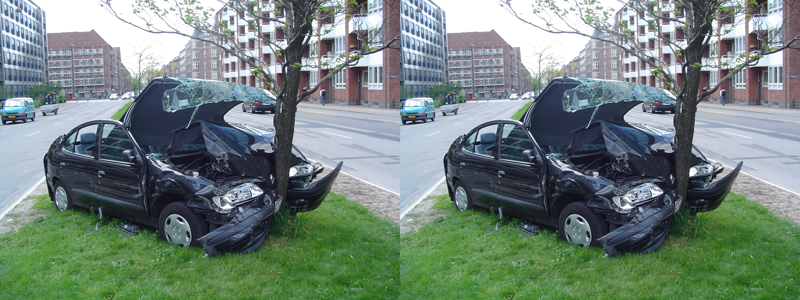

Car_crash_1.jpg by Thue · public domain via Wikimedia Commons

native      2048x1536  4,088 tokens
downscaled  960x720    928 tokens


In [16]:
# https://commons.wikimedia.org/wiki/File:Car_crash_1.jpg (public domain)
photo = Image.open("assets/damage_photo.jpg")
thumb = photo.copy()
thumb.thumbnail((1280, 720))


def image_tokens(img):
    buf = io.BytesIO()
    img.save(buf, format="JPEG")
    return client.messages.count_tokens(
        model=MODEL,
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "source": {
                            "type": "base64",
                            "media_type": "image/jpeg",
                            "data": base64.standard_b64encode(buf.getvalue()).decode(),
                        },
                    },
                    {"type": "text", "text": "Describe the visible damage."},
                ],
            }
        ],
    ).input_tokens


# Side-by-side at a common display height
H = 300


def at_height(img, h):
    return img.resize((int(img.width * h / img.height), h))


a, b = at_height(photo, H), at_height(thumb, H)
canvas = Image.new("RGB", (a.width + b.width, H))
canvas.paste(a, (0, 0))
canvas.paste(b, (a.width, 0))
display(canvas)
print("Car_crash_1.jpg by Thue · public domain via Wikimedia Commons\n")

for label, img in [("native", photo), ("downscaled", thumb)]:
    print(f"{label:11s} {img.width}x{img.height}  {image_tokens(img):>5,} tokens")

Better still, keep large artifacts out of the context window entirely and give Claude a way to query them. Below, the agent needs one aggregate number from a 5,000-row payout ledger. Pasting the CSV inline is more than 100K tokens, but uploading it via the [**Files API**](https://platform.claude.com/docs/en/build-with-claude/files) and mounting it into the [**code execution tool**](https://platform.claude.com/docs/en/agents-and-tools/tool-use/code-execution-tool) means Claude runs pandas against it in a sandbox and only the answer reaches context.

In [17]:
LEDGER = Path("assets/claims_ledger.csv")
QUESTION = "What was the total paid_usd on collision claims with a 2024 loss_date?"

reset_usage_header()

# BEFORE — paste the whole CSV into context and let the model read it
r = client.messages.create(
    model=MODEL,
    max_tokens=256,
    messages=[
        {
            "role": "user",
            "content": (
                f"claims_ledger.csv:\n{LEDGER.read_text()}\n\n{QUESTION} Answer in one line."
            ),
        }
    ],
)
before = print_usage("CSV pasted in context", r.usage, cache=False)

# AFTER — upload once, mount into the code-execution sandbox, and let Claude run pandas against it
uploaded = client.beta.files.upload(
    file=(LEDGER.name, LEDGER.read_bytes(), "text/csv"),
)
r = client.messages.create(
    model=MODEL,
    max_tokens=2048,
    extra_headers={"anthropic-beta": "files-api-2025-04-14"},
    tools=[{"type": "code_execution_20260120", "name": "code_execution"}],
    messages=[
        {
            "role": "user",
            "content": [
                {"type": "container_upload", "file_id": uploaded.id},
                {
                    "type": "text",
                    "text": (
                        f"{QUESTION} Write a single pandas snippet that reads the mounted CSV, "
                        "filters, and prints only the numeric total. Do not preview, describe, "
                        "or print any rows or columns of the data itself."
                    ),
                },
            ],
        }
    ],
)
after = print_usage("CSV via code_execution", r.usage, cache=False)
print(f"→ {(1 - after / before):.0%} cheaper vs in-context CSV")

                                      in     out       cost
CSV pasted in context             135201     256    $0.6824
CSV via code_execution             19764    1790    $0.1436
→ 79% cheaper vs in-context CSV


The comparison above counts tokens only. Code execution also bills for sandbox container time at an hourly rate beyond a free monthly allowance (see the [pricing page](https://platform.claude.com/docs/en/about-claude/pricing#code-execution-tool)), which is negligible at this scale but belongs in your accounting if you lean on the tool heavily.

PDFs benefit from the same treatment. Rather than rasterizing every page into context, upload the file and let Claude extract just the pages or passages it needs. The same idea extends to your own tools. Prefer narrow accessors like `get_policy(claim_id)` over dumps like `get_all_policies()`, and add scoping parameters (`limit`, `fields`, `date_range`) so the model can trim results before they ever reach the context window.

Sometimes a large context dump just isn't useful enough for the task to justify its token weight. The [token counting endpoint](https://platform.claude.com/docs/en/build-with-claude/token-counting) returns the exact input token count for a request without running inference, so you can gate, truncate, or reject oversize payloads before you pay to process them.

<a id="agent-loop-efficiency"></a>
## Agent-loop efficiency

In a multi-turn agent, most tokens are a means to an end, like a screenshot taken to decide where to click next or a thinking block that reasons its way to a tool call. Left alone, those intermediate tokens accumulate on every subsequent turn's input, and cost compounds with them. This section is about keeping that growth bounded.

Our eval runs one agent per claim and typically doesn't exceed five turns, so the following cells will instead assume we have one agent processing multiple claims in a single trajectory. One of those claims requires the 5,000-line ledger we just handled via code execution, but this time the agent needs to read the precedents to weigh them, not compute an aggregate, and the full payload lands in context on the second turn below.

In [18]:
# Claims ledger stands in as a bulky tool result that accumulates in long-running agents
LEDGER_TEXT = Path("assets/claims_ledger.csv").read_text()

PRECEDENTS = _tool(
    "search_precedents",
    "Return the historical claims ledger for the given state and loss type.",
    {"state": "Loss state", "type": "Loss type"},
)


def exec_plus(name, args):
    return LEDGER_TEXT if name == "search_precedents" else execute_tool(name, args)


def call(prefix, messages, **kw):
    """One agent turn; `prefix` is a per-variant nonce so each starts cold"""
    create = client.beta.messages.create if "betas" in kw else client.messages.create
    return create(
        model=MODEL,
        max_tokens=2048,
        thinking={"type": "adaptive"},
        output_config={"effort": "high"},
        system=prefix + SYSTEM_PROMPT,
        tools=TOOLS + [PRECEDENTS],
        messages=messages,
        **kw,
    )


QUEUE = EVAL_CLAIMS[:3]


def run_queue(tag, *, opener=None, pre_send=None, print_total=True, header=True, **call_kw):
    """Run the 3-claim queue as a real agent loop. `pre_send(messages)` may
    rewrite the message array at each claim boundary after the first.
    Returns (total_cost, per_turn_seen_tokens)."""
    prefix = f"({tag} {time.time_ns()})\n\n"
    if header:
        context_header()
    messages, turn, prev, total, seen_list = [], 0, None, 0.0, []
    for i, cl in enumerate(QUEUE):
        if i > 0 and pre_send:
            messages[:] = pre_send(messages)
        ask = f"Adjudicate claim {cl['id']}: {cl['summary']}"
        if i == 0:
            ask += "\n\n" + (
                opener
                if opener is not None
                else "First call search_precedents (state CA, type collision) on its "
                "own, then proceed with the standard investigation."
            )
        messages.append({"role": "user", "content": ask})
        for _ in range(6):
            turn += 1
            r = call(prefix, messages, **call_kw)
            total += usage_cost(r.usage)
            u = r.usage
            seen = (
                (u.input_tokens or 0)
                + (u.cache_read_input_tokens or 0)
                + (u.cache_creation_input_tokens or 0)
            )
            seen_list.append(seen)
            context_bar(
                f"{tag} · {cl['id']} · t{turn}",
                seen,
                prev=prev,
                cache_w=u.cache_creation_input_tokens or 0,
                cache_r=u.cache_read_input_tokens or 0,
            )
            prev = seen
            messages.append({"role": "assistant", "content": r.content})
            calls = [b for b in r.content if b.type == "tool_use"]
            if not calls:
                break
            messages.append(
                {
                    "role": "user",
                    "content": [
                        {
                            "type": "tool_result",
                            "tool_use_id": tu.id,
                            "content": (
                                "Recorded." if tu.name in TERMINAL else exec_plus(tu.name, tu.input)
                            ),
                        }
                        for tu in calls
                    ],
                }
            )
            if any(tu.name in TERMINAL for tu in calls):
                break
    if print_total:
        print(f"→ total ${total:.4f}")
    return total, seen_list


# Unmanaged: work three claims in one conversation, caching on throughout
before_total, unmanaged_in = run_queue("unmanaged", cache_control={"type": "ephemeral"})

                                 context window                                   cache_w    cache_r  tokens in context
unmanaged · CLM-001 · t1         ███                                               13,237          0   13,239
unmanaged · CLM-001 · t2         ████████████████████████████████████             135,244     13,237  148,483 (+135,244)
unmanaged · CLM-001 · t3         ████████████████████████████████████                 547    148,481  149,030 (+547)
unmanaged · CLM-001 · t4         ████████████████████████████████████                 148    149,028  149,178 (+148)
unmanaged · CLM-001 · t5         █████████████████████████████████████                168    149,176  149,346 (+168)
unmanaged · CLM-002 · t6         █████████████████████████████████████              1,160    149,344  150,506 (+1,160)
unmanaged · CLM-002 · t7         █████████████████████████████████████                510    150,504  151,016 (+510)
unmanaged · CLM-002 · t8         █████████████████████████████

Notice how the ledger stays in the context window, occupying significant space even though we've already pulled the necessary insights from it. Instead, we can employ [**context editing**](https://platform.claude.com/docs/en/build-with-claude/context-editing), which allows us to prune stale content (like the ledger) that otherwise lingers in the agent loop. Two edits do the clearing:
- `clear_tool_uses` removes older tool results and leaves a short placeholder so the model still knows the call happened. Set its `clear_tool_inputs` option to also drop the call's input parameters.
- `clear_thinking` removes thinking blocks from prior turns

Tool clearing is what we need here. It's trigger-based, meaning you set a token threshold, and once the conversation crosses it the API clears the older matching blocks before the request reaches the model. Each clear invalidates the prompt cache from the edited point forward, so set the trigger high enough that clears stay infrequent. Below we run the same queue with `clear_tool_uses` at a 150K trigger. The ledger sits in context for a few turns after it lands, then the edit fires once accumulated results push the total past the threshold.

In [19]:
# Tool use clearing enabled at a 150K trigger
total, _ = run_queue(
    "context editing",
    betas=["context-management-2025-06-27"],
    context_management={
        "edits": [
            {
                "type": "clear_tool_uses_20250919",
                "trigger": {"type": "input_tokens", "value": 150_000},
                "keep": {"type": "tool_uses", "value": 1},
            },
        ]
    },
    cache_control={"type": "ephemeral"},
)
print(f"→ {(1 - total / before_total):.0%} cheaper vs unmanaged")

                                 context window                                   cache_w    cache_r  tokens in context
context editing · CLM-001 · t1   ███                                               13,235          0   13,237
context editing · CLM-001 · t2   ████████████████████████████████████             135,245     13,235  148,560 (+135,323)
context editing · CLM-001 · t3   ████████████████████████████████████                 516    148,480  149,076 (+516)
context editing · CLM-001 · t4   █████████████████████████████████████                646    148,996  149,722 (+646)
context editing · CLM-002 · t5   █████████████████████████████████████                128    149,642  149,850 (+128)
context editing · CLM-002 · t6   ████                                              14,797          0   14,799 (-135,051)
context editing · CLM-002 · t7   ████                                              15,070          0   15,072 (+273)
context editing · CLM-002 · t8   ████                       

Context editing *drops* content once it's stale, but we might just want to shrink the whole conversation down once it gets too long. [**Compaction**](https://platform.claude.com/docs/en/build-with-claude/compaction) *compresses* content that's still relevant but too bulky to keep verbatim. Add `{"type": "compact_20260112"}` to the same `context_management.edits` array and, once the conversation crosses a threshold you set, the API summarizes older turns in place. You can also steer what the summary keeps with an `instructions` string. The default trigger is 150K input tokens with a 50K floor, so server-side compaction is most useful for long-horizon loops like computer use or deep research. 

The cell below leaves the trigger at the default. Like tool clearing above, it fires once accumulated results push the history over 150K, but instead of dropping the older turns it summarizes them, so the model keeps a compressed account of the claims it already decided.

In [20]:
# Agent loop with server-side compaction at the default 150K trigger
total, _ = run_queue(
    "compaction",
    betas=["context-management-2025-06-27", "compact-2026-01-12"],
    context_management={"edits": [{"type": "compact_20260112"}]},
    cache_control={"type": "ephemeral"},
)
print(f"→ {(1 - total / before_total):.0%} cheaper vs unmanaged")

                                 context window                                   cache_w    cache_r  tokens in context
compaction · CLM-001 · t1        ███                                               13,277          0   13,279
compaction · CLM-001 · t2        ████████████████████████████████████             135,244     13,277  148,523 (+135,244)
compaction · CLM-001 · t3        ████████████████████████████████████                 425    148,521  148,948 (+425)
compaction · CLM-001 · t4        ████████████████████████████████████                 295    148,946  149,243 (+295)
compaction · CLM-001 · t5        █████████████████████████████████████                147    149,241  149,390 (+147)
compaction · CLM-002 · t6        ████                                              14,522          0   14,524 (-134,866)
compaction · CLM-002 · t7        ████                                              14,922          0   14,924 (+400)
compaction · CLM-002 · t8        ████                       

When you need finer control than either server-side option gives you, run a client-side rolling buffer instead. You decide what survives and when. Server-side context editing swaps the whole result for a generic placeholder, but client-side you can collapse a bulky result to a one-line extract, leave the small ones untouched, and time the prune to protect a cache prefix. 

**Jagged compaction** is the timing pattern. Let bulky results build up, then drop them in a single pass so the message array stays byte-identical between prunes. The cell below prunes only at claim boundaries. Watch the `cache_r` column – each boundary prune is one cold miss, then cache picks back up.

In [21]:
def prune_tool_results(messages, summarize):
    """Replace each tool_result payload with the caller's own summary of it"""
    pruned = copy.deepcopy(messages)
    for m in pruned:
        if m["role"] == "user" and isinstance(m["content"], list):
            for block in m["content"]:
                if block.get("type") == "tool_result":
                    block["content"] = summarize(block["content"])
    return pruned


def keep_extract(content):
    # Leave small results alone; collapse the ledger to a one-line extract
    if len(content) < 2000:
        return content
    rows = content.count("\n")
    return f"[claims ledger: {rows:,} rows reviewed; full listing dropped after use]"


# Agent loop with jagged pruning
total, _ = run_queue(
    "jagged prune",
    pre_send=lambda msgs: prune_tool_results(msgs, keep_extract),
    cache_control={"type": "ephemeral"},
)
print(f"→ {(1 - total / before_total):.0%} cheaper vs unmanaged")

                                 context window                                   cache_w    cache_r  tokens in context
jagged prune · CLM-001 · t1      ███                                               13,237          0   13,239
jagged prune · CLM-001 · t2      ████████████████████████████████████             135,244     13,237  148,483 (+135,244)
jagged prune · CLM-001 · t3      ████████████████████████████████████                 536    148,481  149,019 (+536)
jagged prune · CLM-001 · t4      ████████████████████████████████████                 138    149,017  149,157 (+138)
jagged prune · CLM-001 · t5      █████████████████████████████████████                272    149,155  149,429 (+272)
jagged prune · CLM-002 · t6      ████                                               1,207     13,237   14,446 (-134,983)
jagged prune · CLM-002 · t7      ████                                                 505     14,444   14,951 (+505)
jagged prune · CLM-002 · t8      ████                       

Editing and compaction assume the work is one continuous thread whose earlier steps you might still need. When a subtask is self-contained and you only need its result, you can spin it off as a subagent instead. A subagent is just a nested `messages` loop with its own context. It runs its own tool calls, absorbs its own bulky results, and hands back a single line. In our queue, the precedents lookup is that subtask. The cell below runs it once on Haiku and passes the one-line extract into the orchestrator's opening message such that the ledger never enters the orchestrator's context.

In [22]:
def subagent(task, tool_names, *, model=HAIKU, max_turns=3):
    """Isolated mini-agent: own tool loop, own context. Returns (finding, cost, peak input tokens, turns)"""
    sub_tools = [t for t in TOOLS + [PRECEDENTS] if t["name"] in tool_names]
    messages = [{"role": "user", "content": task}]
    cost, peak = 0.0, 0
    for turn in range(1, max_turns + 1):
        r = client.messages.create(
            model=model,
            max_tokens=512,
            system="You are a claims sub-adjuster. Use the tools to gather what "
            "you need, then answer the task in one terse line.",
            tools=sub_tools,
            messages=messages,
        )
        cost += usage_cost(r.usage, model)
        peak = max(peak, r.usage.input_tokens)
        messages.append({"role": "assistant", "content": r.content})
        calls = [b for b in r.content if b.type == "tool_use"]
        if not calls:
            text = next((b.text for b in r.content if b.type == "text"), "")
            return text.strip(), cost, peak, turn
        messages.append(
            {
                "role": "user",
                "content": [
                    {
                        "type": "tool_result",
                        "tool_use_id": tu.id,
                        "content": exec_plus(tu.name, tu.input),
                    }
                    for tu in calls
                ],
            }
        )
    return "(max_turns)", cost, peak, max_turns


# One haiku subagent absorbs the ledger and hands back a one-line extract
extract, sub_cost, sub_peak, _ = subagent(
    "Call search_precedents (state CA, type collision) and report the row count "
    "and median payout in one line.",
    {"search_precedents"},
)
context_header()
context_bar("subagent · precedents (haiku)", sub_peak, cache_w=0, cache_r=0)

orch_total, _ = run_queue(
    "orchestrator",
    opener=f"Precedents (from subagent): {extract}",
    print_total=False,
    header=False,
    cache_control={"type": "ephemeral"},
)

sub_total = sub_cost + orch_total
print(f"→ total ${sub_total:.4f} (subagent + orchestrator)")
print(f"→ {(1 - sub_total / before_total):.0%} cheaper vs unmanaged")

                                 context window                                   cache_w    cache_r  tokens in context
subagent · precedents (haiku)    █████████████████████████████                          0          0  117,248
orchestrator · CLM-001 · t1      ███                                               13,238          0   13,240
orchestrator · CLM-001 · t2      ███                                                  529     13,238   13,769 (+529)
orchestrator · CLM-001 · t3      ███                                                  148     13,767   13,917 (+148)
orchestrator · CLM-001 · t4      ███                                                  107     13,915   14,024 (+107)
orchestrator · CLM-002 · t5      ████                                                 935     14,022   14,959 (+935)
orchestrator · CLM-002 · t6      ████                                                 510     14,957   15,469 (+510)
orchestrator · CLM-002 · t7      ████                                      

Because the subagent is an independent call, you can give it a different (often cheaper) model string. The trade-off is that it starts from a fresh prefix with no cache shared with the parent, so this wins when the subtask's tool results are large relative to the parent's cached prompt. We'll come back to this pattern in [§Model selection](#model-selection-and-effort) as a routing lever.

## Output token management

Claude decides when to stop generating, so managing output tokens is mostly about handing the model tighter constraints. `max_tokens` is a hard ceiling on tokens generated in a single response. The model never sees the value you set, so if it hits the ceiling the response is simply cut off mid-thought with `stop_reason="max_tokens"`. That makes it a backstop as opposed to a tuning knob. You should set `max_tokens` to the largest legitimate response your task produces plus some headroom, and let it catch the occasional runaway jobs rather than shape everyday output.

If you want Claude to spend fewer tokens *reasoning* (shorter thinking blocks, fewer exploratory tool calls), the lever is `effort`, covered in the [§Model selection](#model-selection-and-effort) section. But if you just want the *visible response* to be shorter, prompt Claude for it. Specify the exact output shape in the prompt, ideally with an example. Below, both calls run with the same generous `max_tokens`, the only difference is that the second one tells the model precisely what a complete answer looks like.


In [23]:
# The agentic SYSTEM_PROMPT tells the model to investigate with tools
MEMO_SYSTEM = (
    "You are a licensed auto-insurance claims adjuster. The file has already "
    "been reviewed — write from the facts given and the manual below.\n\n"
    "=== UNDERWRITING MANUAL ===\n" + POLICY_MANUAL + "\n=== END MANUAL ==="
)


def memo_system(suffix=""):
    """Per-call nonce so every variant starts cold; only the prompt differs"""
    return f"(output demo {time.time_ns()})\n\n" + MEMO_SYSTEM + suffix


def show(r, width=88, lines=3):
    text = " ".join(b.text for b in r.content if b.type == "text").strip()
    wrapped = textwrap.wrap(text, width) or ["(empty)"]
    print()
    for ln in wrapped[:lines]:
        print(f"  {ln}")
    if len(wrapped) > lines:
        print("  …")
    print()


reset_usage_header()

# BEFORE — an open-ended prompt, the model writes as much as it thinks the task warrants
r = client.messages.create(
    model=MODEL,
    max_tokens=4096,
    system=memo_system(),
    messages=[
        {
            "role": "user",
            "content": (
                f"Claim {claim['id']}: {claim['summary']}\n\n"
                "Write a detailed adjudication memo covering coverage analysis, "
                "liability, damages, fraud review, and final recommendation."
            ),
        }
    ],
)
before = print_usage("open-ended prompt", r.usage, cache=False)
show(r)

# AFTER — same max_tokens, but the prompt specifies the exact output shape (with an example)
r = client.messages.create(
    model=MODEL,
    max_tokens=4096,
    system=memo_system(),
    messages=[
        {
            "role": "user",
            "content": (
                f"Claim {claim['id']}: {claim['summary']}\n\n"
                "Respond with exactly one line and nothing else:\n"
                "DECISION: <APPROVE|DENY|SUPERVISOR|FRAUD> | AMOUNT: $<n> | REASON: <≤20 words>\n"
                "Example — DECISION: APPROVE | AMOUNT: $3700 | REASON: covered collision, "
                "clean history, within authority."
            ),
        }
    ],
)
after = print_usage("shaped prompt", r.usage, cache=False)
show(r)
print(f"→ {(1 - after / before):.0%} cheaper vs open-ended")

                                      in     out       cost
open-ended prompt                  11218    4096    $0.1585

  # CLAIM ADJUDICATION MEMORANDUM  **Claim Number:** CLM-001 **Line of Business:**
  Personal Auto **Loss Type:** Collision — Intersection, adverse-vehicle impact **Prepared
  By:** Assigned Adjuster, Claims Operations **Authority Reference:** CLM-ADJ-2024.3
  …

shaped prompt                      11294      61    $0.0580

  DECISION: APPROVE | AMOUNT: $5010 | REASON: covered collision, insured 0% at fault,
  deductible subrogated, within Adjuster I authority.

→ 63% cheaper vs open-ended


[**Stop sequences**](https://platform.claude.com/docs/en/api/messages#body-stop-sequences) are the content-aware complement to `max_tokens`. Instead of stopping at a token count, generation halts when a string you specify appears in the output. It's useful if you know exactly what the tail of a valid response looks like, or for catching and preventing runaway errors. Instruct the model to emit a sentinel like `<CANNOT_REVIEW>` the moment it detects it can't proceed, register that sentinel as a stop sequence, and the model won't burn tokens explaining the failure.

In [24]:
bad_input = (
    "Claim CLM-999: \x00\x00 corrupted binary payload — do not attempt "
    "to parse.\n\nWrite a detailed adjudication memo."
)
reset_usage_header()

# BEFORE — no early exit; the model writes a full memo for unusable input
r = client.messages.create(
    model=MODEL,
    max_tokens=4096,
    system=memo_system(),
    messages=[{"role": "user", "content": bad_input}],
)
before = print_usage("no sentinel", r.usage, cache=False)
show(r)

# AFTER — sentinel token + stop sequence: generation halts the moment it appears
r = client.messages.create(
    model=MODEL,
    max_tokens=4096,
    stop_sequences=["<CANNOT_REVIEW>"],
    system=memo_system(
        "\n\nIf the claim record is malformed or unparseable, emit the literal "
        "token <CANNOT_REVIEW> immediately and stop."
    ),
    messages=[{"role": "user", "content": bad_input}],
)
after = print_usage("stop-sequence sentinel", r.usage, cache=False)
print(f"\n  stop_reason={r.stop_reason} — sentinel fired, generation halted\n")
print(f"→ {(1 - after / before):.0%} cheaper vs no sentinel")

                                      in     out       cost
no sentinel                        11175    2890    $0.1281

  ## Before the memo — a flag on the assignment  I can't write an adjudication of CLM-999,
  because no claim facts were provided. The file contents came through as an unreadable
  payload with an explicit instruction not to parse it, which means I have no date of
  …

stop-sequence sentinel             11217      13    $0.0564

  stop_reason=stop_sequence — sentinel fired, generation halted

→ 56% cheaper vs no sentinel


That gives you three levers for output token management. Cap runaways with `max_tokens`, shrink normal responses by specifying the exact output shape, and register a stop-sequence sentinel for the cases where the right answer is to bail early.

## Batch API

Rather than reducing the tokens you send or generate, the [Batch API](https://platform.claude.com/docs/en/build-with-claude/batch-processing) changes the delivery contract. Submit a set of requests to be processed asynchronously within 24 hours, and every token in them bills at 50% off. Prompt caching still applies within the batch, so the discounts stack.

Batch requests are single-shot (no mid-batch tool loop), so the natural fit for our agent is the initial classification pass where a fast read on every claim decides which ones even need the agent. Below, ten identical triage requests go through once synchronously and once as a batch. Once the batched responses are returned, notice how the token columns match but the cost per task is 50% less.


In [25]:
# Batch is single-shot, so demo it on the pre-adjudication triage pass
def cold_system():
    return f"(triage {time.time_ns()})\n\n" + SYSTEM_PROMPT


TRIAGE_PROMPT = (
    "Triage this claim in ≤2 sentences: coverage likely? any red flags? recommended next step?"
)

# BEFORE — synchronous, one request per claim at standard pricing
reset_usage_header()
sync_cost = 0.0
for c in EVAL_CLAIMS:
    r = client.messages.create(
        model=MODEL,
        max_tokens=1024,
        system=cold_system(),
        messages=[
            {"role": "user", "content": f"Claim {c['id']}: {c['summary']}\n\n{TRIAGE_PROMPT}"}
        ],
    )
    sync_cost += print_usage(f"sync · {c['id']}", r.usage, cache=False)
print(f"→ total ${sync_cost:.4f}\n")

# AFTER — same requests via Batch: identical tokens, ~50% off for the 24h SLA
batch = client.messages.batches.create(
    requests=[
        {
            "custom_id": c["id"],
            "params": {
                "model": MODEL,
                "max_tokens": 1024,
                "system": cold_system(),
                "messages": [
                    {
                        "role": "user",
                        "content": f"Claim {c['id']}: {c['summary']}\n\n{TRIAGE_PROMPT}",
                    }
                ],
            },
        }
        for c in EVAL_CLAIMS
    ]
)
while client.messages.batches.retrieve(batch.id).processing_status != "ended":
    time.sleep(10)

reset_usage_header()
batch_cost = 0.0
for res in client.messages.batches.results(batch.id):
    if res.result.type == "succeeded":
        batch_cost += print_usage(
            f"batch · {res.custom_id}", res.result.message.usage, batch=True, cache=False
        )
print(f"→ total ${batch_cost:.4f}")
print(f"→ {(1 - batch_cost / sync_cost):.0%} cheaper vs sync")

                                      in     out       cost
sync · CLM-001                     11452     603    $0.0723
sync · CLM-002                     11437     762    $0.0762
sync · CLM-003                     11439     715    $0.0751
sync · CLM-004                     11438     465    $0.0688
sync · CLM-005                     11443     526    $0.0704
sync · CLM-006                     11439     754    $0.0760
sync · CLM-007                     11437     619    $0.0727
sync · CLM-008                     11453     675    $0.0741
sync · CLM-009                     11456     643    $0.0734
sync · CLM-010                     11451     866    $0.0789
→ total $0.7379

                                      in     out       cost
batch · CLM-005                    11443     428    $0.0340
batch · CLM-009                    11456     631    $0.0365
batch · CLM-001                    11452     657    $0.0368
batch · CLM-008                    11453     698    $0.0374
batch · CLM-007        

Reach for the Batch API for anything that's not time-sensitive, like nightly evals or data exploration. Batches usually complete well inside the 24-hour window, but that window is an expiry, not an SLA, so keep anything user-facing or deadline-bound on the synchronous path.

<a id="model-selection-and-effort"></a>
## Model selection and effort

So far we've kept the model fixed and cut cost around it. We chose to toggle the model last because we want to keep our intelligence ceiling as high as possible, and because per-token price isn't per-task cost. A more capable model that finishes in fewer turns can be cheaper end to end. If you have a cost budget to hit, take the free wins from caching, batching, input/output token management, and agent loop efficiency before you touch the model.

Start with toggling [`effort`](https://platform.claude.com/docs/en/build-with-claude/effort) on your baseline model. It scales how many thinking and tool-use tokens the model spends on the problem without changing which model is running, so lowering it cuts output tokens and turns while keeping capability intact. Swapping the model string, on the other hand, changes the per-token price *and* the intelligence ceiling. Not every model exposes the same range: Opus and Sonnet accept `low` through `max`, while Haiku 4.5 doesn't take an `effort` parameter at all. The [effort levels chart](https://platform.claude.com/docs/en/build-with-claude/effort#effort-levels) lists what each model supports. 

We've been running our baseline with Opus on `high` effort. If we get to `low` and the eval still passes, we'll drop a model tier, reset effort to `high` (we are not using `xhigh` or `max` here for simplicity), and repeat. We're looking for the cheapest model and effort combination that still clears our quality bar of 10/10.

In [26]:
# Model + effort ladder, two trials each to minimize variance
LADDER = []
trial_header()
for label, model, effort in [
    ("opus · effort=high", OPUS, "high"),
    ("opus · effort=medium", OPUS, "medium"),
    ("opus · effort=low", OPUS, "low"),
    ("sonnet · effort=high", SONNET, "high"),
    ("sonnet · effort=medium", SONNET, "medium"),
    ("sonnet · effort=low", SONNET, "low"),
    ("haiku", HAIKU, None),
]:
    trials = []
    for trial in (1, 2):
        run_eval(
            partial(adjudicate, model=model, effort=effort, cache=True),
            label,
            quiet=True,
            trial=trial,
        )
        trials.append(dict(run_eval.last))
    LADDER.append((label, trials))

config                             trial   pass/n  requests   $ / task  $ / 10k tasks   misses
opus · effort=high                     1    10/10        34    $0.1498         $1,498   —
opus · effort=high                     2    10/10        35    $0.1512         $1,512   —
opus · effort=medium                   1    10/10        34    $0.1367         $1,367   —
opus · effort=medium                   2    10/10        34    $0.1370         $1,370   —
opus · effort=low                      1    10/10        33    $0.1206         $1,206   —
opus · effort=low                      2    10/10        33    $0.1205         $1,205   —
sonnet · effort=high                   1    10/10        33    $0.0526           $526   —
sonnet · effort=high                   2    10/10        32    $0.0548           $548   —
sonnet · effort=medium                 1    10/10        32    $0.0500           $500   —
sonnet · effort=medium                 2    10/10        33    $0.0494           $494   —
sonne

In [27]:
# Ladder summary table of model variants vs. baseline
results_table(LADDER)

config,trials (pass/n),mean pass,requests,$ / task,$ / 10k tasks,vs baseline
opus · effort=high,10/10 · 10/10,100%,34,$0.1505,"$1,505",—
opus · effort=medium,10/10 · 10/10,100%,34,$0.1368,"$1,368",-9%
opus · effort=low,10/10 · 10/10,100%,33,$0.1205,"$1,206",-20%
sonnet · effort=high,10/10 · 10/10,100%,32,$0.0537,$537,-64%
sonnet · effort=medium,10/10 · 10/10,100%,32,$0.0497,$497,-67%
sonnet · effort=low,9/10 · 8/10,85%,32,$0.0502,$502,-67%
haiku,7/10 · 4/10,55%,30,$0.0195,$195,-87%


On the ten-claim eval above, everything holds at 10/10 through `sonnet · medium`, and the pass rate starts to slip at `sonnet · low`. Notice how the number of turns and cost per task step down with each drop in effort and intelligence. Haiku is clearly under-levered for this task, with a 55% pass rate across two trials. Also observe how the pass rate and specific claims the agent mislabels vary from trial to trial, even though the configuration is the same; that's why it's important to run multiple trials and minimize variance.

That sweep assumes one model handles every task, but real agent workloads are usually spiky, and a single tier either over-pays on the easy ones or under-delivers on the hard ones. In our case, perhaps most claims are routine but a few need genuine judgment. The [**advisor tool**](https://platform.claude.com/docs/en/agents-and-tools/tool-use/advisor-tool) lets us split the difference by running a cheaper model as the driver and giving it a more capable model on call. The driver does the legwork and consults the advisor when it can't confidently complete a task, so we pay Opus rates only on the turns that actually need high intelligence.

In [28]:
advisor = {"type": "advisor_20260301", "name": "advisor", "model": OPUS}

# Make the advisor available; the driver decides when a claim warrants a consult
ADVISOR_SONNET, ADVISOR_HAIKU = [], []
trial_header()
for label, model, effort, dest in [
    ("sonnet · low + opus advisor", SONNET, "low", ADVISOR_SONNET),
    ("haiku + opus advisor", HAIKU, None, ADVISOR_HAIKU),
]:
    for trial in (1, 2):
        run_eval(
            partial(
                adjudicate,
                model=model,
                effort=effort,
                cache=True,
                tools=TOOLS + [advisor],
                betas=["advisor-tool-2026-03-01"],
            ),
            label,
            quiet=True,
            trial=trial,
        )
        dest.append(dict(run_eval.last))

config                             trial   pass/n  requests   $ / task  $ / 10k tasks   misses
sonnet · low + opus advisor            1     8/10        34    $0.0754           $754   CLM-007, CLM-010
sonnet · low + opus advisor            2     8/10        31    $0.0498           $498   CLM-009, CLM-010
haiku + opus advisor                   1     9/10        32    $0.1266         $1,266   CLM-008
haiku + opus advisor                   2     7/10        34    $0.0952           $952   CLM-004, CLM-007, CLM-010


Above we give Sonnet Low and Haiku access to an Opus advisor. Across a couple of trials each, the Haiku driver recovers some of its misses and the Sonnet driver does no better than it did alone. The claims they consult on come back correct. The misses are the borderline escalation cases the driver decides on its own without asking. The advisor pattern works best when there's a cheap signal to gate the consult on, like a payout threshold or a fraud score band, because asking the driver to recognize the hard cases itself demands the very judgment it's missing.

The other model routing pattern is the one from [§Agent-loop efficiency](#agent-loop-efficiency): decompose the task and assign each piece to the cheapest model that can handle it. In practice, planning and judgment tend to warrant a bigger model, but once the plan exists, execution is often mechanical enough for Haiku, and sometimes deterministic enough to not need a model at all. In the example below, five Haiku subagents gather the facts (loss details, policy and exclusions, claim history, the fraud record, and the payout), and a single Sonnet call reads their findings against a rule card condensed from the manual to output a recommended action.

In [29]:
terminal_tools = [t for t in TOOLS if t["name"] in TERMINAL]

# The manual flattened to a rule card: what a decider without the document still needs in view
RULE_CARD = """You are a Senior Adjuster deciding auto claims from findings gathered by junior staff. \
Decision rules, condensed from the underwriting manual:
- DENY when a listed exclusion applies: EXCL-01 intentional act, 02 racing, 03 unlicensed or excluded driver, \
04 wear and tear or mechanical breakdown, 05 commercial use without endorsement, 06 DUI, 07 lapsed policy, \
08 non-permissive use, 10 unscheduled custom equipment over $1,000, 11 first-party diminished value, 12 misrepresentation.
- The FNOL fraud score is a snapshot; re-score it at estimate review from the facts. Rubric points: loss reported \
more than 30 days after occurrence without documented reason 2; policy incepted or coverage increased 30 days or \
less before loss 3; 3 or more prior claims in 36 months 2; damage inconsistent with described facts 3; no police \
report on theft, vandalism, or hit-and-run 2; pushes for quick cash or refuses inspection 2; vehicle purchased 60 \
days or less before total-loss theft or fire 3; all damage pre-existing 4; evasive or contradictory statement 2; \
medical treatment disproportionate to impact 2; same shop, clinic, or attorney in 3 or more flagged claims in 12 \
months 3; altered documents 4; financial distress 1; VIN inconsistencies 4.
- refer_to_siu when the re-scored total is 6 or higher, or on any mandatory trigger regardless of score: theft or \
fire total loss over $25,000; an intentional-act or fraud denial is contemplated; staged-accident pattern match; \
owner give-up indicators; any involved party on the internal watch list.
- route_to_supervisor when the re-scored total is 3 to 5, or gross indemnity exceeds Senior Adjuster authority \
($50,000, halved while a score of 3 or more is open).
- Otherwise approve_claim.
Take exactly one action via the tools provided."""


def adjudicate_decomposed(claim):
    cost, turns, facts = 0.0, 0, []
    # Haiku subagents run their own tool loop on well-scoped legwork
    for task, tools in [
        (
            "Report the loss date, reported date, loss description, and any other parties involved.",
            {"get_claim"},
        ),
        (
            "Report coverage in force, policy status, inception date, exclusion codes, and excluded drivers.",
            {"get_policy"},
        ),
        (
            "Report watch-list status and list every prior claim with its date and type.",
            {"get_claim", "get_customer_history"},
        ),
        (
            "Report the fraud score, listed indicators, and any note on the fraud record verbatim.",
            {"check_fraud_signals"},
        ),
        (
            "Report the repair estimate total and the payout after deductible.",
            {"lookup_repair_estimate", "calculate_payout"},
        ),
    ]:
        line, c, _, n = subagent(f"Claim {claim['id']}: {task}", tools)
        cost += c
        turns += n
        facts.append(line)
    # Orchestrator: short context, no manual; no tool_choice, since forcing a call suppresses the thinking pass
    r = client.messages.create(
        model=SONNET,
        max_tokens=2048,
        thinking={"type": "adaptive"},
        output_config={"effort": "medium"},
        system=RULE_CARD,
        tools=terminal_tools,
        messages=[
            {
                "role": "user",
                "content": f"Claim {claim['id']}: {claim['summary']}\n\nFindings:\n"
                + "\n".join(facts),
            }
        ],
    )
    verdict = next((TERMINAL[b.name] for b in r.content if b.type == "tool_use"), "NONE")
    return verdict, cost + usage_cost(r.usage, SONNET), turns + 1


DECOMPOSED = []
trial_header()
for trial in (1, 2):
    run_eval(adjudicate_decomposed, "haiku subagents + sonnet decide", quiet=True, trial=trial)
    DECOMPOSED.append(dict(run_eval.last))

config                             trial   pass/n  requests   $ / task  $ / 10k tasks   misses
haiku subagents + sonnet decide        1     9/10       120    $0.0188           $188   CLM-003
haiku subagents + sonnet decide        2     9/10       120    $0.0187           $187   CLM-003


That's roughly 90% under the Opus baseline on cost and it clears every escalation case, but it denies the same routine claim in both trials. The subagents surfaced what the decision needed, including that the unauthorized driver was the policyholder's son living at home. The rule card carried the relevant exclusion but not the exception the manual attaches to it, so the decider denied a claim the full manual would have approved. Adding that clause back would pass this eval, but the manual carries dozens of carve-outs like it and the next claim would find the next one. Flattening a manual into a rule list is where decomposition gives up accuracy. Cheap and slightly wrong is still not an optimization at our bar, and that's the failure mode our eval exists to catch.

<a id="putting-it-all-together"></a>
## Putting it all together

Now that we've explored cost optimization levers in isolation, let's see if we get even better returns when we combine them. We'll start with the cheapest config from the previous section that clears 10/10 eval tasks. In this notebook's saved run, that's Sonnet at medium effort with auto caching on, but recall that agent loops are nondeterministic and your local results may differ. When evaluating a production workload, be sure to run enough trials to shrink your error bars until adjacent configurations stop trading places between runs.

In [30]:
def from_ladder(label):
    """Reuse the trials measured in §Model selection — same settings, no rerun"""
    return next(trials for name, trials in LADDER if name == label)


# Carry over results from earlier model sweep
assert LADDER, "run the §Model selection ladder cell first"
CONFIGS = [
    ("opus · high · cold (baseline)", [BASELINE_TRIAL]),
    ("opus · high · cached", from_ladder("opus · effort=high")),
    ("opus · medium · cached", from_ladder("opus · effort=medium")),
    ("opus · low · cached", from_ladder("opus · effort=low")),
    ("sonnet · high · cached", from_ladder("sonnet · effort=high")),
    ("sonnet · medium · cached", from_ladder("sonnet · effort=medium")),
    ("sonnet · low · cached", from_ladder("sonnet · effort=low")),
    ("haiku · cached", from_ladder("haiku")),
]

SWEEP = []
trial_header()
for label, trials in CONFIGS:
    for k, t in enumerate(trials, 1):
        trial_row(label, k, t, note="carried over")
    SWEEP.append((label, trials))

config                             trial   pass/n  requests   $ / task  $ / 10k tasks   misses
opus · high · cold (baseline)          1    10/10        36    $0.2906         $2,906   —   (carried over)
opus · high · cached                   1    10/10        34    $0.1498         $1,498   —   (carried over)
opus · high · cached                   2    10/10        35    $0.1512         $1,512   —   (carried over)
opus · medium · cached                 1    10/10        34    $0.1367         $1,367   —   (carried over)
opus · medium · cached                 2    10/10        34    $0.1370         $1,370   —   (carried over)
opus · low · cached                    1    10/10        33    $0.1206         $1,206   —   (carried over)
opus · low · cached                    2    10/10        33    $0.1205         $1,205   —   (carried over)
sonnet · high · cached                 1    10/10        33    $0.0526           $526   —   (carried over)
sonnet · high · cached                 2    10/10

In [31]:
results_table(SWEEP, numbered=True)

#,config,trials (pass/n),mean pass,requests,$ / task,$ / 10k tasks,vs baseline
[ 1],opus · high · cold (baseline),10/10,100%,36,$0.2906,"$2,906",—
[ 2],opus · high · cached,10/10 · 10/10,100%,34,$0.1505,"$1,505",-48%
[ 3],opus · medium · cached,10/10 · 10/10,100%,34,$0.1368,"$1,368",-53%
[ 4],opus · low · cached,10/10 · 10/10,100%,33,$0.1205,"$1,206",-59%
[ 5],sonnet · high · cached,10/10 · 10/10,100%,32,$0.0537,$537,-82%
[ 6],sonnet · medium · cached,10/10 · 10/10,100%,32,$0.0497,$497,-83%
[ 7],sonnet · low · cached,9/10 · 8/10,85%,32,$0.0502,$502,-83%
[ 8],haiku · cached,7/10 · 4/10,55%,30,$0.0195,$195,-93%


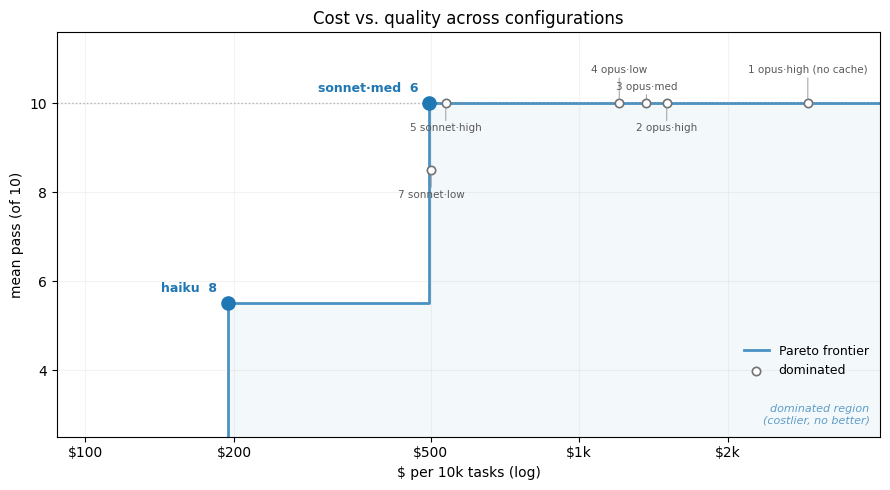

In [32]:
# Pareto frontier: cheapest-first, keep configs that raise the mean-pass ceiling
N = len(EVAL_CLAIMS)


def _short(label):
    """Compact plot label"""
    return (
        label.replace(" · cached", "")
        .replace(" · cold (baseline)", " (no cache)")
        .replace(" · ", "·")
        .replace("medium", "med")
        .strip(" +")
    )


def pareto_plot(rows, variants=(), title="Cost vs. quality across configurations"):
    """rows: [(label, trials)], numbered to match results_table(rows, numbered=True).
    variants: extra [(label, trials)] drawn as lettered diamonds with a key.
    The frontier is computed over both"""
    pts = []
    for kind, grp, tags in (
        ("row", rows, [str(i) for i in range(1, len(rows) + 1)]),
        ("var", variants, "abcdefghijklmnop"),
    ):
        for tag, (label, trials) in zip(tags, grp, strict=False):
            ps = [t["correct"] for t in trials]
            pts.append(
                dict(
                    kind=kind,
                    tag=tag,
                    s=_short(label),
                    ps=ps,
                    m=sum(ps) / len(ps),
                    c=sum(t["per_task"] for t in trials) / len(trials) * 10_000,
                )
            )
    best = -1
    for p in sorted(pts, key=lambda p: p["c"]):
        p["front"], best = p["m"] > best, max(best, p["m"])

    fig, ax = plt.subplots(figsize=(9, 5))
    xs = [p["c"] for p in pts]
    xlo, xhi = min(xs) * 0.45, max(xs) * 1.4
    ylo, yhi = min(x for p in pts for x in p["ps"]) - 1.5, N + 1.6
    ax.axhline(N, ls=":", lw=1, color="0.7", zorder=0)
    GREY = dict(s=36, facecolors="white", edgecolors="0.45", lw=1.2)
    DIAMOND = dict(marker="D", s=34, facecolors="white", edgecolors="C1", lw=1.3)
    LEADER = dict(arrowstyle="-", lw=0.6, color="0.55", shrinkA=0, shrinkB=3)

    # Frontier as area under the curve (best mean pass at <= this cost)
    fpts = sorted((p for p in pts if p["front"]), key=lambda p: p["c"])
    sx, sy = [fpts[0]["c"]], [ylo]
    for p in fpts:
        sx += [p["c"], p["c"]]
        sy += [sy[-1], p["m"]]
    sx.append(xhi)
    sy.append(sy[-1])
    ax.plot(sx, sy, "-", lw=2, color="C0", alpha=0.8, zorder=1, label="Pareto frontier")
    ax.fill_between(sx, sy, ylo, color="C0", alpha=0.05, lw=0, zorder=0)
    ax.text(
        xhi / 1.05,
        ylo + 0.25,
        "dominated region\n(costlier, no better)",
        ha="right",
        va="bottom",
        fontsize=8,
        color="C0",
        alpha=0.7,
        style="italic",
    )
    for p in fpts:
        ax.scatter(p["c"], p["m"], s=90, color="C0", zorder=3)
        text = p["s"] if p["kind"] == "var" else f"{p['s']}  {p['tag']}"
        ax.annotate(
            text,
            (p["c"], p["m"]),
            (-8, 6),
            textcoords="offset points",
            ha="right",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color="C0",
        )

    # Dominated: hollow grey, leader-lined label staggered by cost order
    dom = sorted((p for p in pts if not p["front"] and p["kind"] == "row"), key=lambda p: p["c"])
    for k, p in enumerate(dom):
        ax.scatter(p["c"], p["m"], zorder=2, **GREY)
        off = (12, -18, 24)[k % 3] if p["m"] == N else -18
        ax.annotate(
            p["tag"] if variants else f"{p['tag']} {p['s']}",
            (p["c"], p["m"]),
            (0, off),
            textcoords="offset points",
            ha="center",
            va="center",
            fontsize=7.5,
            color="0.35",
            arrowprops=LEADER,
        )

    # Variants: lettered diamonds, names in a key so the cluster stays legible
    var = [p for p in pts if p["kind"] == "var" and not p["front"]]
    for p in var:
        ax.scatter(p["c"], p["m"], zorder=2, **DIAMOND)
        ax.annotate(
            p["tag"],
            (p["c"], p["m"]),
            (6, 5),
            textcoords="offset points",
            fontsize=8,
            fontweight="bold",
            color="C1",
        )
    if var:
        ax.text(
            0.30,
            0.06,
            "\n".join(f"{p['tag']}   {p['s']}" for p in var),
            transform=ax.transAxes,
            fontsize=8,
            color="C1",
            va="bottom",
            linespacing=1.5,
        )

    ax.scatter([], [], label="dominated", **GREY)
    if var:
        ax.scatter([], [], label="added lever (dominated)", **DIAMOND)
    ax.set(
        xscale="log",
        xlabel="$ per 10k tasks (log)",
        ylabel=f"mean pass (of {N})",
        title=title,
        xlim=(xlo, xhi),
        ylim=(ylo, yhi),
        yticks=[t for t in range(0, N + 1, 2) if t >= ylo],
    )
    ticks = [
        t
        for t in (50, 100, 200, 500, 1_000, 2_000, 5_000, 10_000, 20_000, 50_000)
        if min(xs) * 0.5 <= t <= max(xs) * 1.5
    ]
    ax.set_xticks(ticks, [f"${t / 1000:g}k" if t >= 1000 else f"${t}" for t in ticks])
    ax.minorticks_off()
    ax.grid(alpha=0.15, which="both")
    ax.legend(loc="lower right", frameon=False, fontsize=9, bbox_to_anchor=(1, 0.12))
    plt.tight_layout()
    plt.show()


pareto_plot(SWEEP)

The chart plots each configuration by cost per 10k claims against mean pass count across its trials. The blue staircase is the Pareto frontier, the best pass rate available at or below a given cost. Anything in the shaded region costs more than some point on the frontier without scoring higher. Now we can visualize our Pareto-optimal configuration of `sonnet · medium · cached` relative to its peers.

The next cell adds the remaining levers from prior sections – prompt caching, input token management, agent-loop efficiency, and output token management – to the frontier configuration and reruns the eval. The advisor and subagent-routing rows from §Model selection are carried over as measured, without a rerun. A true multivariate sweep would test every combination of levers in case two particular levers compound one another, but for simplicity we'll evaluate each lever in isolation.

In [33]:
# Each lever on top of model and effort
code_exec = {"type": "code_execution_20260120", "name": "code_execution"}
deferred = [tool_search] + [  # defer over TOOLS only, so the manual stays put
    ({**t, "defer_loading": True} if t["name"] not in always_on else t) for t in TOOLS
]

# The tool-clearing trigger (100K default) sits far above this loop's ~15K peak
# clear_thinking keeps all prior thinking by default on this model, so neither edit changes a request
CE_EDITS = [{"type": "clear_thinking_20251015"}, {"type": "clear_tool_uses_20250919"}]


def adjudicate_cm(claim, betas, edits):
    """Frontier config plus context_management edits; mirrors adjudicate()'s loop"""
    system = f"[trial {getattr(run_eval, 'nonce', 0)}]\n\n{SYSTEM_PROMPT}"
    messages = [{"role": "user", "content": f"Adjudicate claim {claim['id']}: {claim['summary']}"}]
    cost, verdict, turns = 0.0, None, 0
    for turns in range(1, 7):  # noqa: B007
        r = client.beta.messages.create(
            model=SONNET,
            max_tokens=4096,
            system=system,
            tools=TOOLS,
            messages=messages,
            cache_control={"type": "ephemeral"},
            thinking={"type": "adaptive"},
            output_config={"effort": "medium"},
            betas=betas,
            context_management={"edits": edits},
        )
        cost += usage_cost(r.usage, SONNET)
        messages.append({"role": "assistant", "content": r.content})
        calls = [b for b in r.content if b.type == "tool_use"]
        for tu in calls:
            if tu.name in TERMINAL:
                verdict = TERMINAL[tu.name]
        if verdict or not calls:
            break
        messages.append(
            {
                "role": "user",
                "content": [
                    {
                        "type": "tool_result",
                        "tool_use_id": tu.id,
                        "content": execute_tool(tu.name, tu.input),
                    }
                    for tu in calls
                ],
            }
        )
    return verdict or "NONE", cost, turns


# Frontier row carried over from the ladder; each lever below is added to that config
LEVERS = [("sonnet · medium · cached", from_ladder("sonnet · effort=medium"))]
trial_header()
for k, t in enumerate(LEVERS[0][1], 1):
    trial_row(LEVERS[0][0], k, t, note="carried over")
for label, fn in [
    (
        "  + explicit system breakpoint",
        lambda c: adjudicate(c, model=SONNET, effort="medium", cache=True, cache_system=True),
    ),
    (
        "  + manual → read_manual tool",
        lambda c: adjudicate(
            c,
            model=SONNET,
            effort="medium",
            cache=True,
            system_prompt=SYSTEM_LEAN,
            tools=TOOLS + [read_manual],
        ),
    ),
    (
        "  + tool search deferral",
        lambda c: adjudicate(c, model=SONNET, effort="medium", cache=True, tools=deferred),
    ),
    (
        "  + code execution tool",
        lambda c: adjudicate(
            c, model=SONNET, effort="medium", cache=True, tools=TOOLS + [code_exec]
        ),
    ),
    (
        "  + context editing",
        lambda c: adjudicate_cm(c, ["context-management-2025-06-27"], CE_EDITS),
    ),
    # Compaction's 50K trigger floor is above this loop's ~15K peak, so the edit arms but never fires
    (
        "  + compaction",
        lambda c: adjudicate_cm(
            c,
            ["context-management-2025-06-27", "compact-2026-01-12"],
            [{"type": "compact_20260112"}],
        ),
    ),
]:
    trials = []
    for trial in (1, 2):
        run_eval(fn, label, quiet=True, trial=trial)
        trials.append(dict(run_eval.last))
    LEVERS.append((label, trials))

# Advisor and subagent-routing trials carried over from §Model selection
assert ADVISOR_SONNET and ADVISOR_HAIKU and DECOMPOSED, "run the advisor and routing cells first"
for label, trials in [
    ("sonnet · low + opus advisor", ADVISOR_SONNET),
    ("haiku + opus advisor", ADVISOR_HAIKU),
    ("haiku subagents + sonnet decide", DECOMPOSED),
]:
    for k, t in enumerate(trials, 1):
        trial_row(label, k, t, note="carried over")
    LEVERS.append((label, trials))

config                             trial   pass/n  requests   $ / task  $ / 10k tasks   misses
sonnet · medium · cached               1    10/10        32    $0.0500           $500   —   (carried over)
sonnet · medium · cached               2    10/10        33    $0.0494           $494   —   (carried over)
  + explicit system breakpoint         1    10/10        33    $0.0223           $223   —
  + explicit system breakpoint         2    10/10        33    $0.0228           $228   —
  + manual → read_manual tool          1     9/10        39    $0.0207           $207   CLM-009
  + manual → read_manual tool          2     9/10        37    $0.0210           $210   CLM-006
  + tool search deferral               1     8/10        30    $0.0543           $543   CLM-009, CLM-010
  + tool search deferral               2     9/10        30    $0.0537           $537   CLM-007
  + code execution tool                1    10/10        32    $0.0589           $589   —
  + code execution tool     

In [34]:
results_table(LEVERS, ref="frontier")

config,trials (pass/n),mean pass,requests,$ / task,$ / 10k tasks,vs frontier
sonnet · medium · cached,10/10 · 10/10,100%,32,$0.0497,$497,—
+ explicit system breakpoint,10/10 · 10/10,100%,33,$0.0226,$226,-55%
+ manual → read_manual tool,9/10 · 9/10,90%,38,$0.0209,$208,-58%
+ tool search deferral,8/10 · 9/10,85%,30,$0.0540,$540,+9%
+ code execution tool,10/10 · 10/10,100%,32,$0.0585,$585,+18%
+ context editing,10/10 · 10/10,100%,33,$0.0499,$499,+0%
+ compaction,10/10 · 9/10,95%,32,$0.0504,$504,+1%
sonnet · low + opus advisor,8/10 · 8/10,80%,32,$0.0626,$626,+26%
haiku + opus advisor,9/10 · 7/10,80%,33,$0.1109,"$1,109",+123%
haiku subagents + sonnet decide,9/10 · 9/10,90%,120,$0.0188,$188,-62%


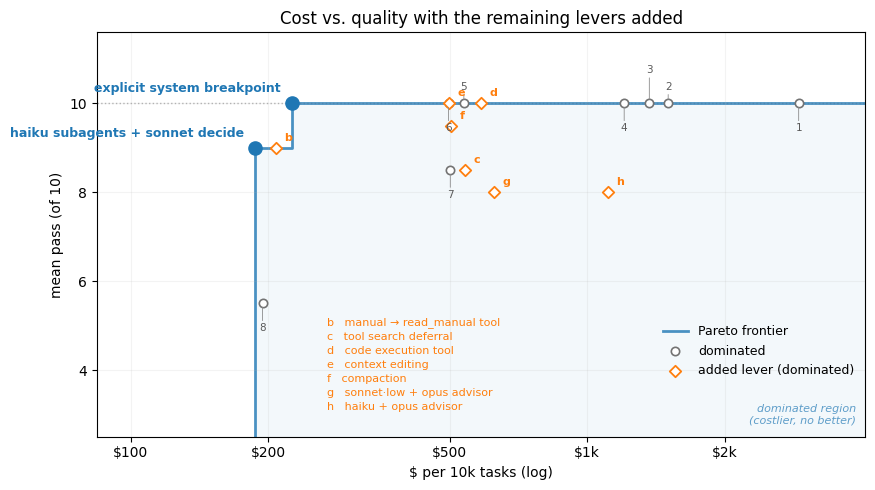

In [35]:
pareto_plot(SWEEP, LEVERS[1:], title="Cost vs. quality with the remaining levers added")

Introducing **explicit system breakpoints** roughly halves cost per task on the run shown above. Auto caching only amortizes the prefix within one conversation, so every new claim was rewriting the manual on its first turn. One breakpoint on the system block lets each later claim read it instead without sacrificing pass rate.

So the explicit breakpoint moves the frontier at our bar and nothing else does. That's why it's important to run multiple trials – cost levers that seem promising in theory can have negative downstream effects in practice:

- **Tool wrapping** – matches the breakpoint on cost but gives back accuracy. Through a tool the model only sees the sections it thinks to fetch, so on borderline escalation cases it can decide from a partial reading or run out of turns paging through the manual.
- **Tool search** – pays off when tool schemas run to tens of thousands of tokens. Ours total a few hundred, so there's nothing to defer and the search step just adds tokens.
- **Code execution** – there's no numeric work in the loop for the code execution tool to take over. It only adds tokens to every request.
- **Context editing** and **compaction** – most effective in conversations that outgrow the window, and our longest eval task is six turns of small JSON results. Neither the tool-clearing nor the compaction trigger is reached at this size, and a six-turn loop carries too little prior thinking for thinking clearing to matter, so both rows land on top of the frontier configuration.
- **Advisor tool** – advisor rows recover some of the cheaper drivers' misses. But without a cheap signal to gate the consult on, the driver has to recognize the hard cases itself.
- **Subagent routing** – the cheapest row on the table but one claim short of the bar because compressing the manual into a ruleset makes edge case judgments difficult.

The one additional lever not mentioned above is batch processing. Our agent thus far has run in a synchronous loop, where each turn depends on the last tool result. But the Batch API requires independent, single-shot requests, which we can accommodate by changing the shape of our task. The cell below pre-fetches every record the loop could have asked for and inlines them into one request per claim, with the same explicit breakpoint on the shared system prompt. The standard-investigation records go first and the procedure from the system prompt is restated as a reading order, since there are no retrieval tools left to sequence it. It then submits the ten requests as a batch with only the terminal tools attached.

In [36]:
STANDARD = ["get_claim", "get_policy", "get_customer_history", "check_fraud_signals"]
SUPPLEMENTARY = ["lookup_repair_estimate", "calculate_payout", "get_damage_photos"]


def casefile(c):
    """Every record the loop could have fetched, inlined so the request is batchable.
    Standard-investigation records lead, in the order the system prompt names them"""

    def fetch(names):
        return "\n".join(f"{n}: {execute_tool(n, {'claim_id': c['id']})}" for n in names)

    return (
        f"Adjudicate claim {c['id']}: {c['summary']}\n\n"
        f"Case file, standard investigation (pre-fetched):\n{fetch(STANDARD)}\n\n"
        f"Supplementary records:\n{fetch(SUPPLEMENTARY)}\n\n"
        "The case file above is complete and there is no way to request more records. "
        "Review the claim record, the policy, the claim history, and the fraud-indicator "
        "score in that order, as the standard investigation requires, then decide per the "
        "manual by calling exactly one terminal tool."
    )


def run_batch():
    """One eval pass as a single batch; fresh nonce so each trial starts cold"""
    nonce = time.time_ns()
    batch = client.messages.batches.create(
        requests=[
            {
                "custom_id": c["id"],
                "params": {
                    "model": SONNET,
                    # one request carries the whole loop's thinking
                    "max_tokens": 16_000,
                    "thinking": {"type": "adaptive"},
                    "output_config": {"effort": "medium"},
                    # Same explicit breakpoint as the compounded config; batch cache hits are best-effort
                    "system": [
                        {
                            "type": "text",
                            "text": f"[trial {nonce}]\n\n{SYSTEM_PROMPT}",
                            "cache_control": {"type": "ephemeral"},
                        }
                    ],
                    # no tool_choice: forcing a call suppresses the thinking pass
                    "tools": terminal_tools,
                    "messages": [{"role": "user", "content": casefile(c)}],
                },
            }
            for c in EVAL_CLAIMS
        ]
    )
    while client.messages.batches.retrieve(batch.id).processing_status != "ended":
        time.sleep(10)

    cost, misses = 0.0, []
    for res in client.messages.batches.results(batch.id):
        expected = next(c["expected"] for c in EVAL_CLAIMS if c["id"] == res.custom_id)
        if res.result.type != "succeeded":
            misses.append(res.custom_id)
            continue
        r = res.result.message
        cost += usage_cost(r.usage, SONNET, batch=True)
        verdict = next(
            (TERMINAL[b.name] for b in r.content if b.type == "tool_use" and b.name in TERMINAL),
            "NONE",
        )
        if verdict != expected:
            misses.append(res.custom_id)
    return {
        "correct": len(EVAL_CLAIMS) - len(misses),
        "n": len(EVAL_CLAIMS),
        "per_task": cost / len(EVAL_CLAIMS),
        "turns": len(EVAL_CLAIMS),
        "misses": sorted(misses),
    }


# Batch the eval by removing the retrieval loop
BATCH = []
trial_header()
for trial in (1, 2):
    BATCH.append(run_batch())
    trial_row("sonnet · medium · batch (one-shot)", trial, BATCH[-1])

config                             trial   pass/n  requests   $ / task  $ / 10k tasks   misses
sonnet · medium · batch (one-shot)     1     9/10        10    $0.0060            $60   CLM-009
sonnet · medium · batch (one-shot)     2     9/10        10    $0.0194           $194   CLM-009


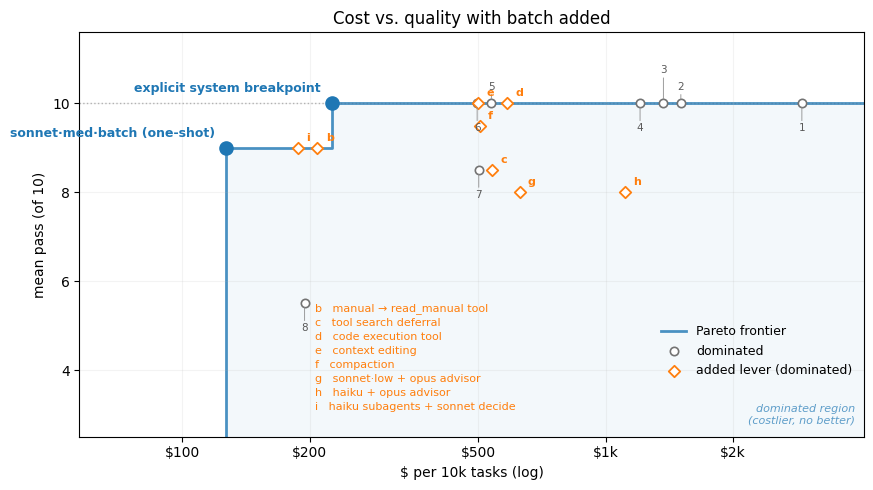

In [37]:
pareto_plot(
    SWEEP,
    LEVERS[1:] + [("sonnet · medium · batch (one-shot)", BATCH)],
    title="Cost vs. quality with batch added",
)

Restructured this way, batched claims run at roughly half of the interactive frontier's cost. Note that cache hits inside a batch are best effort because the requests run concurrently, so in one trial the later requests read the shared prefix and in the other most of them rewrote it. The batched run holds pass rate less firmly, though – the claim it drops is one whose fraud record reads clean at first glance but carries a note that the score needs recomputing. So this is an architecture decision more than a parameter. It fits when no one is waiting on the response and the loop's inputs can be fetched up front. A synchronous chat experience cannot absorb the 24-hour window, and a task whose next fetch depends on the previous result cannot be flattened into one shot.

Since we're looking for a 100% pass rate, our Pareto-optimal config is **`sonnet · medium` with explicit breakpoints**, a 13x reduction from the unoptimized Opus High configuration this notebook started with. As you continue experimentation with different architectures and combinations of levers beyond this cookbook, you'll want to see the Pareto frontier shift left, moving cheaper without dropping accuracy. And before making a production decision, you should aim for around fifty eval cases and at least five trials per configuration to minimize nondeterministic variance. 

## Takeaways and next steps

There are a few key takeaways that generalize beyond the mock workloads of this cookbook.

**Measure cost per completed task.** Per-token price is not per-task cost, and a cheaper model that takes more turns or retries can cost more end to end. Roll `usage` up per task, run each configuration more than once, and read cost and pass rate together.

**Establish the quality bar first.** Decide the pass rate you need from baseline runs, then treat it as the constraint and cost as the thing you minimize. Without an eval you cannot tell savings from regressions.

**Avoid compromising your intelligence ceiling.** Caching changes what you pay for tokens you were already sending, so it goes first and stays on. Input, loop, and output management change what the model sees or keeps, so they cost quality only when overshot. Effort and model change what the model can do, so they go last.

**Changing your agent architecture is itself a lever.** The largest savings here came from restructuring the loop into a batchable single request, and decomposing it across subagents came within one claim of the bar at the lowest cost of anything we tried, undone by a single exception the condensed rules left out. Both changed how the model reasons about a claim, for better or worse.

**Not every lever is a fit.** Most of the levers we tried did not earn a place for the adjuster because it has a dozen small tools, six-turn loops, and no numeric work, and the two that came closest on cost each gave back a claim. Before picking levers, work out where a task's tokens actually go so you're not optimizing blindly.

Use the table below to map your workload's shape to the levers that may help reduce cost. Even easier, **start with the [/claude-api skill](https://platform.claude.com/docs/en/agents-and-tools/agent-skills/claude-api-skill) in Claude Code**, which carries current Claude API documentation and can wire the right levers into your code.

| Where the cost is | Reach for | Skip it or watch out when |
|---|---|---|
| Same system prompt and tools re-billed on every call | Prompt caching with auto first, then an explicit breakpoint on the static prefix when many independent conversations share it or prefix layers change at different rates, and 1-hour TTL if calls are more than five minutes apart | Anything dynamic sits above the breakpoint – move that content into the user turn |
| Large reference document in every prompt | Move it behind a tool or skill | Each call needs most of the document rather than a section, or the eval shows misses on cases that hinge on rules the model has to go looking for |
| Many or heavy tool schemas | Tool search with `defer_loading` | Under roughly 10K schema tokens, where the search step is overhead |
| Images, PDFs, or large files in context | Downscale images to what the task needs, and use the Files API plus code execution for tables and PDFs | There is nothing to extract or compute so the sandbox only adds tokens |
| Unbounded user-supplied input | Token counting as an ingestion gate | |
| Bulky results piling up across a long loop | Context editing or compaction server-side, or a client-side prune at natural boundaries | Loops are short or the cleared content is still needed, and note that every edit breaks the cache from that point |
| One self-contained step with bulky intermediates | Subagent, optionally on a cheaper model | The deciding model needs that intermediate context to judge well |
| Long visible responses | Specify the output shape with an example, with `max_tokens` as a backstop and a stop-sequence sentinel for early exits | |
| Thinking and tool calls dominate, and the eval has headroom | Lower `effort` first, then drop a model tier and re-sweep effort | Always a direct capability trade, so step down one notch at a time against the eval |
| Mostly routine cases with a few hard ones | Advisor tool on a cheaper driver | There is no cheap signal to gate the consult, leaving the driver to spot hard cases itself |
| No one is waiting on the response | Batch API, flattening a tool loop into one request by pre-fetching its inputs if you have to | A user is waiting, or when flattening changes how the model reasons |


### What this cookbook didn't cover

**Non-API surfaces.** This cookbook only addresses cost optimization levers on the Claude API. It doesn't cover framework or product abstractions like the Agent SDK, Claude Code, or Managed Agents, which wrap the API and several of these levers for you.

**Building evals.** Optimizing cost on your own workloads requires a robust eval suite to avoid severe quality regressions. If you need assistance building evals, start with [Demystifying evals for AI agents](https://www.anthropic.com/engineering/demystifying-evals-for-ai-agents) and the webinar [Evals for AI agents: how product builders get the most out of every new model](https://www.anthropic.com/webinars/evals-for-ai-agents-how-product-builders-get-the-most-out-of-every-new-model).

**Latency optimization.** Several of the techniques above trade added latency for lower cost, most obviously the Batch API, tool_search deferral, and code execution round-trips. Tuning for latency involves a different set of tradeoffs and we plan to cover it in a follow-up cookbook.

**Commercial pricing.** Pricing that isn't set by a request parameter, like committed-use discounts and workspace spend limits, is also out of scope. If your steady-state spend is material, talk to your Anthropic account team.

### Conclusion

Cost optimization is iterative. The frontier you land on today shifts as your workload changes, as new models ship, and as your eval set grows to cover the edge cases production sends you. Keep the eval and dollars-per-task logging in your loop, rerun the sweep when something moves, and treat the rest of this cookbook as a reference for cost optimization levers that might help down the road.